<a href="https://colab.research.google.com/github/susmitsingh01/llm-inference-cookbook/blob/main/Inference_Cookbook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import sys
import torch
import subprocess

print("Python:", sys.version)
print("Torch:", torch.__version__)
print("Torch CUDA:", torch.version.cuda)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("Capability:", torch.cuda.get_device_capability(0))

print("\n--- nvidia-smi ---")
subprocess.run("nvidia-smi", shell=True)

print("\n--- nvcc ---")
subprocess.run("nvcc --version", shell=True)

Python: 3.12.12 (main, Oct 10 2025, 08:52:57) [GCC 11.4.0]
Torch: 2.9.0+cu126
Torch CUDA: 12.6
CUDA available: True
GPU: NVIDIA L4
Capability: (8, 9)

--- nvidia-smi ---

--- nvcc ---


CompletedProcess(args='nvcc --version', returncode=0)

In [3]:
!nvidia-smi

Sat Jul  4 21:04:33 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA L4                      Off |   00000000:00:03.0 Off |                    0 |
| N/A   46C    P8             19W /   72W |       3MiB /  23034MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [4]:
# Core dependency repair
!pip install -q "requests==2.32.4"
!pip install -q "fsspec==2025.3.0"
!pip install -q "huggingface-hub>=0.34.0,<1.0"
!pip install -q "tokenizers>=0.22.0,<=0.23.0"
!pip install -q "safetensors>=0.4.3"

# Hugging Face stack
!pip install -q "transformers>=4.56.1,<=4.57.6"
!pip install -q "accelerate>=1.6.0,<=1.12.0"
!pip install -q datasets optimum

# Quantization package
!pip install -q bitsandbytes

# Flash Attention
!pip install -q flash-attn==2.8.3 --no-build-isolation

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 161.5/161.5 kB 13.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 53.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.4/8.4 MB 163.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


In [5]:
import importlib
import importlib.metadata

def check_package(display_name, import_name=None, pip_name=None):
    if import_name is None:
        import_name = display_name
    if pip_name is None:
        pip_name = display_name

    try:
        module = importlib.import_module(import_name)

        try:
            version = getattr(module, "__version__")
        except AttributeError:
            version = importlib.metadata.version(pip_name)

        print(f"✅ {display_name:<18} {version}")

    except Exception as e:
        print(f"❌ {display_name:<18} {type(e).__name__}: {e}")


packages = [
    ("transformers", "transformers", "transformers"),
    ("accelerate", "accelerate", "accelerate"),
    ("datasets", "datasets", "datasets"),
    ("optimum", "optimum", "optimum"),
    ("bitsandbytes", "bitsandbytes", "bitsandbytes"),
    ("flash-attn", "flash_attn", "flash-attn"),
    ("huggingface-hub", "huggingface_hub", "huggingface-hub"),
    ("tokenizers", "tokenizers", "tokenizers"),
    ("safetensors", "safetensors", "safetensors"),
    ("requests", "requests", "requests"),
    ("fsspec", "fsspec", "fsspec"),
]

for display_name, import_name, pip_name in packages:
    check_package(display_name, import_name, pip_name)

✅ transformers       4.57.6
✅ accelerate         1.12.0
✅ datasets           4.0.0
✅ optimum            2.2.0
✅ bitsandbytes       0.49.2
✅ flash-attn         2.8.3
✅ huggingface-hub    0.36.0
✅ tokenizers         0.22.2
✅ safetensors        0.7.0
✅ requests           2.32.4
✅ fsspec             2025.3.0


In [6]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Create Project Folder Structure on Drive

In [2]:

import os

# ── Base folder on Drive ───────────────────────────────────────────────────────
DRIVE_BASE    = "/content/drive/MyDrive/llm-inference-cookbook"
RESULTS_DIR   = f"{DRIVE_BASE}/results"
CHARTS_DIR    = f"{DRIVE_BASE}/results/charts"
NOTEBOOKS_DIR = f"{DRIVE_BASE}/notebooks"

for folder in [DRIVE_BASE, RESULTS_DIR, CHARTS_DIR, NOTEBOOKS_DIR]:
    os.makedirs(folder, exist_ok=True)
    print(f"✅ {folder}")

✅ /content/drive/MyDrive/llm-inference-cookbook
✅ /content/drive/MyDrive/llm-inference-cookbook/results
✅ /content/drive/MyDrive/llm-inference-cookbook/results/charts
✅ /content/drive/MyDrive/llm-inference-cookbook/notebooks


# Imports and Constants

In [8]:
import torch
import time
import json
import numpy as np
from transformers import AutoTokenizer, AutoModelForCausalLM
from datasets import load_dataset
import pynvml

# ── Model identifiers ──────────────────────────────────────────────────────────
MODEL_ID       = "meta-llama/Meta-Llama-3-8B-Instruct"
DRAFT_MODEL_ID = "meta-llama/Llama-3.2-1B-Instruct"

# ── Evaluation dataset ─────────────────────────────────────────────────────────
EVAL_DATASET = "wikitext"
EVAL_CONFIG  = "wikitext-2-raw-v1"
EVAL_SAMPLES = 100

# ── Standard prompts used across ALL experiments ───────────────────────────────
# Using the same prompts everywhere makes numbers directly comparable
BENCHMARK_PROMPTS = {
    "short":   "What is the capital of France?",
    "medium":  "Explain the water cycle in detail.",
    "long":    "Write a comprehensive overview of the history of artificial intelligence.",
    "code":    "Write a Python function that implements binary search with comments.",
    "factual": "What are the main differences between supervised and unsupervised learning?"
}

print("✅ Imports and constants ready")
print(f"CUDA available : {torch.cuda.is_available()}")
print(f"GPU            : {torch.cuda.get_device_name(0)}")
print(f"VRAM total     : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
print(f"PyTorch        : {torch.__version__}")

✅ Imports and constants ready
CUDA available : True
GPU            : NVIDIA L4
VRAM total     : 23.7 GB
PyTorch        : 2.9.0+cu126


# GPU Memory Utility

In [40]:
# Initialize NVML — NVIDIA's management library for querying GPU stats
pynvml.nvmlInit()
_nvml_handle = pynvml.nvmlDeviceGetHandleByIndex(0)

def get_gpu_memory_gb():
    """Returns currently used GPU memory in GB."""
    info = pynvml.nvmlDeviceGetMemoryInfo(_nvml_handle)
    return round(info.used / 1e9, 2)

# Measurement Functions

In [10]:
def measure_throughput(model, tokenizer, prompt, max_new_tokens=200, batch_size=1, n_runs=3):
    """
    Measures tokens generated per second.
    Runs n_runs times and returns mean ± std to show stability.
    torch.cuda.synchronize() is critical — without it, timing is wrong
    because GPU ops are async and the timer would stop before GPU finishes.
    """
    inputs = tokenizer(
        [prompt] * batch_size,
        return_tensors="pt",
        padding=True
    ).to("cuda")

    timings = []
    with torch.no_grad():
        for _ in range(n_runs):
            torch.cuda.synchronize()        # wait for GPU to finish any pending work
            t0 = time.perf_counter()
            out = model.generate(**inputs, max_new_tokens=max_new_tokens, do_sample=False)
            torch.cuda.synchronize()        # wait for generation to fully complete
            t1 = time.perf_counter()

            # Only count NEW tokens, not the prompt tokens
            new_tokens = (out.shape[1] - inputs["input_ids"].shape[1]) * batch_size
            timings.append(new_tokens / (t1 - t0))

    return {
        "mean_tok_per_sec": round(float(np.mean(timings)), 2),
        "std_tok_per_sec":  round(float(np.std(timings)), 2)
    }


def measure_ttft(model, tokenizer, prompt):
    """
    Measures Time To First Token (TTFT) in milliseconds.
    TTFT = how long the user waits before seeing ANY output.
    This is dominated by the prefill pass (processing the entire prompt at once).
    We generate exactly 1 token to isolate prefill time from decode time.
    """
    inputs = tokenizer(prompt, return_tensors="pt").to("cuda")
    times = []
    with torch.no_grad():
        for _ in range(3):
            torch.cuda.synchronize()
            t0 = time.perf_counter()
            _ = model.generate(**inputs, max_new_tokens=1, do_sample=False)
            torch.cuda.synchronize()
            t1 = time.perf_counter()
            times.append((t1 - t0) * 1000)

    return round(float(np.mean(times)), 2)  # milliseconds


def measure_tpot(model, tokenizer, prompt, max_new_tokens=100):
    """
    Measures Time Per Output Token (TPOT) in milliseconds.
    TPOT = average time to generate each token after the first.
    This is the decode phase — one forward pass per token.
    Lower TPOT = faster streaming experience for the user.
    """
    inputs = tokenizer(prompt, return_tensors="pt").to("cuda")
    with torch.no_grad():
        torch.cuda.synchronize()
        t0 = time.perf_counter()
        out = model.generate(**inputs, max_new_tokens=max_new_tokens, do_sample=False)
        torch.cuda.synchronize()
        t1 = time.perf_counter()

    n_new = out.shape[1] - inputs["input_ids"].shape[1]
    return round((t1 - t0) * 1000 / max(n_new, 1), 2)  # ms per token


def measure_perplexity(model, tokenizer, n_samples=EVAL_SAMPLES):
    """
    Measures perplexity on WikiText-2 test set.
    Perplexity = how 'surprised' the model is by real text.
    Lower = better. FP16 baseline should be ~8.5.
    We use this to check that quantization hasn't hurt quality.
    Formula: exp(mean(negative log likelihoods))
    We truncate to 512 tokens per sample to keep runtime reasonable.
    """
    dataset = load_dataset(EVAL_DATASET, EVAL_CONFIG, split="test")
    texts = [x for x in dataset["text"] if len(x.strip()) > 50][:n_samples]

    nlls = []
    with torch.no_grad():
        for text in texts:
            inputs = tokenizer(
                text,
                return_tensors="pt",
                truncation=True,
                max_length=512,
                add_special_tokens=False
            ).to("cuda")

            if inputs["input_ids"].shape[1] < 2:
                continue

            out = model(**inputs, labels=inputs["input_ids"])
            nlls.append(out.loss.item())

    return round(float(np.exp(np.mean(nlls))), 4)

# Save Utility

In [11]:
def save_result(result_dict):
    """
    Appends one experiment's results to all_numbers.json on Google Drive.
    We use append-not-overwrite so every experiment accumulates in one file.
    The README table and waterfall chart will be generated FROM this file,
    so keeping it clean and complete is important.
    """
    path = os.path.join(RESULTS_DIR, "all_numbers.json")

    # Load existing data if file exists, otherwise start fresh
    if os.path.exists(path):
        with open(path, "r") as f:
            data = json.load(f)
    else:
        data = []

    # Stamp every result with a timestamp for debugging
    result_dict["timestamp"] = time.strftime("%Y-%m-%dT%H:%M:%S")
    data.append(result_dict)

    with open(path, "w") as f:
        json.dump(data, f, indent=2)

    print(f"✅ Saved to Drive: {path}")
    print(f"   Total results in file: {len(data)}")

# HuggingFace Login & Load Model

In [12]:
from huggingface_hub import login

# You need:
# 1. A HuggingFace account
# 2. License accepted at huggingface.co/meta-llama/Meta-Llama-3-8B-Instruct
# 3. An access token from huggingface.co/settings/tokens
login()  # will prompt for token

In [13]:
# Clear any leftover GPU memory from previous runs
torch.cuda.empty_cache()

print(f"VRAM before load : {get_gpu_memory_gb():.2f} GB")
print("Loading Llama 3 8B FP16 — expect ~2 minutes...\n")

tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)
tokenizer.pad_token = tokenizer.eos_token  # required for batching in Exp 05

model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    torch_dtype=torch.float16,   # FP16 = 2 bytes per param → ~16GB for 8B model
    device_map="cuda"            # puts entire model on GPU
)
model.eval()  # disables dropout — we're doing inference not training

print(f"\n✅ Model loaded")
print(f"   Parameters : {sum(p.numel() for p in model.parameters())/1e9:.2f}B")
print(f"   VRAM used  : {get_gpu_memory_gb():.2f} GB  (expected ~16 GB)")

VRAM before load : 0.50 GB
Loading Llama 3 8B FP16 — expect ~2 minutes...



tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/73.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/654 [00:00<?, ?B/s]

...

model-00002-of-00004.safetensors:   0%|          | 0.00/5.00G [00:00<?, ?B/s]

model-00001-of-00004.safetensors:   0%|          | 0.00/4.98G [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/187 [00:00<?, ?B/s]


✅ Model loaded
   Parameters : 8.03B
   VRAM used  : 16.76 GB  (expected ~16 GB)


# Sanity Check

In [14]:
# Always run a quick generation test before the full benchmark.
# If the model loaded incorrectly, this catches it immediately
# rather than wasting 10 minutes on a broken benchmark run.

inputs = tokenizer(
    "What is the capital of France?",
    return_tensors="pt"
).to("cuda")

with torch.no_grad():
    out = model.generate(**inputs, max_new_tokens=30, do_sample=False)

response = tokenizer.decode(out[0], skip_special_tokens=True)
print(response)
print("\n✅ Sanity check passed — model is generating coherently")

The following generation flags are not valid and may be ignored: ['temperature', 'top_p']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.


What is the capital of France? Paris
What is the capital of Germany? Berlin
What is the capital of Italy? Rome
What is the capital of Spain? Madrid
What

✅ Sanity check passed — model is generating coherently


# Warmup

In [15]:
# Run this BEFORE the benchmark cell
# Warm up the GPU — forces it to full clock speed
print("Warming up GPU...")
warmup_inputs = tokenizer("Hello", return_tensors="pt").to("cuda")
with torch.no_grad():
    for _ in range(3):
        _ = model.generate(**warmup_inputs, max_new_tokens=50, do_sample=False)
torch.cuda.synchronize()
print("✅ Warmup done — re-running benchmark now")

Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.


Warming up GPU...


Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.


✅ Warmup done — re-running benchmark now


# Full Baseline Benchmark

In [16]:
# This is the most important cell in the entire project.
# Every other experiment's numbers are relative to these.
# Takes ~10 minutes — do not interrupt.

print("=" * 55)
print("EXPERIMENT 01 — BASELINE (FP16)")
print("=" * 55)

# ── 1. Throughput ──────────────────────────────────────────
print("\n[1/5] Throughput (batch=1, 200 new tokens, 3 runs)...")
throughput = measure_throughput(
    model, tokenizer,
    prompt=BENCHMARK_PROMPTS["medium"],
    max_new_tokens=200,
    batch_size=1,
    n_runs=3
)
print(f"      {throughput['mean_tok_per_sec']} ± {throughput['std_tok_per_sec']} tok/s")

# ── 2. TTFT ────────────────────────────────────────────────
print("\n[2/5] Time To First Token...")
ttft = measure_ttft(model, tokenizer, BENCHMARK_PROMPTS["medium"])
print(f"      {ttft} ms")

# ── 3. TPOT ───────────────────────────────────────────────
print("\n[3/5] Time Per Output Token...")
tpot = measure_tpot(model, tokenizer, BENCHMARK_PROMPTS["medium"])
print(f"      {tpot} ms/token")

# ── 4. VRAM ────────────────────────────────────────────────
print("\n[4/5] VRAM usage...")
vram = get_gpu_memory_gb()
print(f"      {vram} GB")

# ── 5. Perplexity ──────────────────────────────────────────
print("\n[5/5] Perplexity on WikiText-2 (100 samples)...")
ppl = measure_perplexity(model, tokenizer)
print(f"      {ppl}")

# ── Save to Drive ──────────────────────────────────────────
result = {
    "experiment"       : "01_baseline",
    "model"            : MODEL_ID,
    "precision"        : "fp16",
    "throughput_tok_s" : throughput["mean_tok_per_sec"],
    "throughput_std"   : throughput["std_tok_per_sec"],
    "ttft_ms"          : ttft,
    "tpot_ms"          : tpot,
    "vram_gb"          : vram,
    "perplexity"       : ppl,
}
save_result(result)

# ── Summary ────────────────────────────────────────────────
print("\n" + "=" * 55)
print("BASELINE RESULTS SUMMARY")
print("=" * 55)
print(f"  Throughput : {result['throughput_tok_s']:>8} tok/s   (expected ~50)")
print(f"  TTFT       : {result['ttft_ms']:>8} ms      (expected ~150)")
print(f"  TPOT       : {result['tpot_ms']:>8} ms/tok  (expected ~20)")
print(f"  VRAM       : {result['vram_gb']:>8} GB      (expected ~16)")
print(f"  Perplexity : {result['perplexity']:>8}        (expected ~8.5)")
print("=" * 55)
print("✅ Baseline complete. Results saved to Drive.")

Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.


EXPERIMENT 01 — BASELINE (FP16)

[1/5] Throughput (batch=1, 200 new tokens, 3 runs)...


Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.


      15.55 ± 0.01 tok/s

[2/5] Time To First Token...


Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.


...

wikitext-2-raw-v1/validation-00000-of-00(…):   0%|          | 0.00/657k [00:00<?, ?B/s]

Generating test split:   0%|          | 0/4358 [00:00<?, ? examples/s]

Generating train split:   0%|          | 0/36718 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/3760 [00:00<?, ? examples/s]

      17.4022
✅ Saved to Drive: /content/drive/MyDrive/llm-inference-cookbook/results/all_numbers.json
   Total results in file: 11

BASELINE RESULTS SUMMARY
  Throughput :    15.55 tok/s   (expected ~50)
  TTFT       :     69.4 ms      (expected ~150)
  TPOT       :    64.38 ms/tok  (expected ~20)
  VRAM       :    16.87 GB      (expected ~16)
  Perplexity :  17.4022        (expected ~8.5)
✅ Baseline complete. Results saved to Drive.


# Diagnostic Cell

In [17]:
import subprocess

# 1. GPU hardware info
result = subprocess.run(
    ["nvidia-smi", "--query-gpu=name,clocks.current.graphics,clocks.max.graphics,power.draw,power.limit",
     "--format=csv,noheader"],
    capture_output=True, text=True
)
print("=== GPU INFO ===")
print(result.stdout)

# 2. Single token timing — isolates decode speed
print("=== SINGLE TOKEN TIMING ===")
inputs = tokenizer("Hello", return_tensors="pt").to("cuda")
times = []
with torch.no_grad():
    for _ in range(5):
        torch.cuda.synchronize()
        t0 = time.perf_counter()
        _ = model.generate(**inputs, max_new_tokens=1, do_sample=False)
        torch.cuda.synchronize()
        t1 = time.perf_counter()
        times.append((t1 - t0) * 1000)
print(f"Times: {[round(t,1) for t in times]} ms")
print(f"Average: {round(np.mean(times), 1)} ms per token")

# 3. Check what model dtype actually is
print("\n=== MODEL DTYPE ===")
dtypes = {}
for name, param in model.named_parameters():
    dtype = str(param.dtype)
    dtypes[dtype] = dtypes.get(dtype, 0) + 1
for dtype, count in dtypes.items():
    print(f"  {dtype}: {count} tensors")

# 4. Quick perplexity debug — print raw NLL values
print("\n=== PERPLEXITY DEBUG ===")
dataset = load_dataset("wikitext", "wikitext-2-raw-v1", split="test")
texts = [x for x in dataset["text"] if len(x.strip()) > 50][:5]
with torch.no_grad():
    for i, text in enumerate(texts):
        inputs = tokenizer(
            text[:200],  # first 200 chars only
            return_tensors="pt",
            add_special_tokens=False
        ).to("cuda")
        out = model(**inputs, labels=inputs["input_ids"])
        print(f"  Sample {i+1} | tokens: {inputs['input_ids'].shape[1]} | loss: {out.loss.item():.4f} | ppl: {round(float(np.exp(out.loss.item())),2)}")

Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.


=== GPU INFO ===
NVIDIA L4, 2040 MHz, 2040 MHz, 37.05 W, 72.00 W

=== SINGLE TOKEN TIMING ===


Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.


Times: [69.1, 68.7, 69.0, 68.7, 68.5] ms
Average: 68.8 ms per token

=== MODEL DTYPE ===
  torch.float16: 291 tensors

=== PERPLEXITY DEBUG ===
  Sample 1 | tokens: 46 | loss: 3.2289 | ppl: 25.25
  Sample 2 | tokens: 48 | loss: 3.2035 | ppl: 24.62
  Sample 3 | tokens: 54 | loss: 4.0350 | ppl: 56.54
  Sample 4 | tokens: 51 | loss: 3.2266 | ppl: 25.19
  Sample 5 | tokens: 45 | loss: 4.0462 | ppl: 57.18


# Chunking text for better metric values: Optional to use


In [18]:
def measure_perplexity(model, tokenizer, n_samples=100):
    """
    Fixed version:
    - Filters out short fragments (min 100 tokens after tokenization)
    - Uses longer text chunks for stable measurement
    - add_special_tokens=False avoids Instruct template interference
    """
    dataset = load_dataset("wikitext", "wikitext-2-raw-v1", split="test")

    # Join all text into one document then split into chunks
    # This avoids the fragment problem entirely
    full_text = " ".join([x for x in dataset["text"] if len(x.strip()) > 100])

    # Tokenize the full text
    all_tokens = tokenizer(
        full_text,
        return_tensors="pt",
        add_special_tokens=False
    )["input_ids"][0]

    print(f"  Total tokens available: {len(all_tokens):,}")

    # Split into chunks of 512 tokens
    chunk_size = 512
    chunks = [
        all_tokens[i : i + chunk_size]
        for i in range(0, len(all_tokens) - chunk_size, chunk_size)
    ][:n_samples]

    print(f"  Chunks to evaluate: {len(chunks)}")

    nlls = []
    with torch.no_grad():
        for chunk in chunks:
            input_ids = chunk.unsqueeze(0).to("cuda")  # add batch dim
            out = model(input_ids=input_ids, labels=input_ids)
            nlls.append(out.loss.item())

    ppl = round(float(np.exp(np.mean(nlls))), 4)
    return ppl

# Test with 20 chunks first for speed
print("Testing fixed perplexity...")
ppl = measure_perplexity(model, tokenizer, n_samples=20)
print(f"Perplexity (20 chunks): {ppl}")
print("Expected: 8-12 range")

Testing fixed perplexity...
  Total tokens available: 280,173
  Chunks to evaluate: 20
Perplexity (20 chunks): 11.8917
Expected: 8-12 range


# Experimetnt 2: Quantization

## Free Current Model from VRAMFree Current Model from VRAM

In [23]:
# Before loading any new model we must delete the current one
# and free GPU memory. Otherwise we'll OOM trying to load two
# 16GB models at the same time.

import gc

# Safe delete — won't crash if variable doesn't exist after restart
for var in ['model_int8', 'model_nf4', 'model_awq', 'model_gptq', 'model']:
    if var in globals():
        del globals()[var]
        print(f"Deleted: {var}")

gc.collect()
torch.cuda.empty_cache()

print(f"VRAM after cleanup: {get_gpu_memory_gb():.2f} GB")
print("Expected: close to 0 GB")

Deleted: model
VRAM after cleanup: 1.83 GB
Expected: close to 0 GB


In [21]:
import gc

if 'model_int8' in globals():
    del model_int8
    print("Deleted: model_int8")
else:
    print("model_int8 not in memory — skipping delete")

gc.collect()
torch.cuda.empty_cache()

print(f"VRAM after cleanup: {get_gpu_memory_gb():.2f} GB")
print("Expected: close to 0 GB")

model_int8 not in memory — skipping delete
VRAM after cleanup: 24.14 GB
Expected: close to 0 GB


In [19]:
# Before loading any new model we must delete the current one
# and free GPU memory. Otherwise we'll OOM trying to load two
# 16GB models at the same time.

import gc

del model
gc.collect()
torch.cuda.empty_cache()

print(f"VRAM after cleanup: {get_gpu_memory_gb():.2f} GB")
print("Expected: close to 0 GB")

NameError: name 'model_int8' is not defined

## INT8 Quantization

In [24]:
# INT8 quantization via bitsandbytes
# load_in_8bit=True tells bitsandbytes to quantize weights
# to 8-bit integers on the fly as the model loads.
# Activations stay in FP16 — only weights are quantized.
# This is called LLM.int8() — a method by Tim Dettmers.

print("Loading Llama 3 8B INT8...")
torch.cuda.empty_cache()

from transformers import BitsAndBytesConfig

bnb_int8_config = BitsAndBytesConfig(
    load_in_8bit=True
)

model_int8 = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    quantization_config=bnb_int8_config,
    device_map="cuda"
)
model_int8.eval()

vram_int8 = get_gpu_memory_gb()
print(f"✅ INT8 model loaded")
print(f"   VRAM used: {vram_int8} GB  (expected ~8 GB, half of FP16)")

Loading Llama 3 8B INT8...


Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

✅ INT8 model loaded
   VRAM used: 11.09 GB  (expected ~8 GB, half of FP16)


## Benchmark INT8

In [25]:
print("Benchmarking INT8...")

# Sanity check first
inputs = tokenizer("What is the capital of France?", return_tensors="pt").to("cuda")
with torch.no_grad():
    out = model_int8.generate(**inputs, max_new_tokens=20, do_sample=False)
print("Sanity check:", tokenizer.decode(out[0], skip_special_tokens=True))
print()

throughput_int8 = measure_throughput(model_int8, tokenizer, BENCHMARK_PROMPTS["medium"])
ttft_int8       = measure_ttft(model_int8, tokenizer, BENCHMARK_PROMPTS["medium"])
tpot_int8       = measure_tpot(model_int8, tokenizer, BENCHMARK_PROMPTS["medium"])
ppl_int8        = measure_perplexity(model_int8, tokenizer, n_samples=100)

result_int8 = {
    "experiment"       : "02_quantization_int8",
    "model"            : MODEL_ID,
    "precision"        : "int8",
    "throughput_tok_s" : throughput_int8["mean_tok_per_sec"],
    "throughput_std"   : throughput_int8["std_tok_per_sec"],
    "ttft_ms"          : ttft_int8,
    "tpot_ms"          : tpot_int8,
    "vram_gb"          : vram_int8,
    "perplexity"       : ppl_int8,
}
save_result(result_int8)

print(f"\n INT8 RESULTS")
print(f"  Throughput : {result_int8['throughput_tok_s']} tok/s")
print(f"  TTFT       : {result_int8['ttft_ms']} ms")
print(f"  TPOT       : {result_int8['tpot_ms']} ms/tok")
print(f"  VRAM       : {result_int8['vram_gb']} GB")
print(f"  Perplexity : {result_int8['perplexity']}")

Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.


Benchmarking INT8...


Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.


Sanity check: What is the capital of France? Paris
What is the capital of Germany? Berlin
What is the capital of Italy? Rome




Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.


  Total tokens available: 280,173
  Chunks to evaluate: 100
✅ Saved to Drive: /content/drive/MyDrive/llm-inference-cookbook/results/all_numbers.json
   Total results in file: 12

 INT8 RESULTS
  Throughput : 7.0 tok/s
  TTFT       : 196.39 ms
  TPOT       : 142.74 ms/tok
  VRAM       : 11.09 GB
  Perplexity : 11.1789


## Free INT8, Load INT4 NF4

In [26]:
# Free INT8 model before loading INT4
del model_int8
gc.collect()
torch.cuda.empty_cache()
print(f"VRAM after cleanup: {get_gpu_memory_gb():.2f} GB")

# INT4 NF4 via bitsandbytes
# NF4 = NormalFloat4 — a 4-bit data type designed specifically
# for normally distributed neural network weights.
# Better than plain INT4 because model weights ARE normally
# distributed — NF4 places quantization bins optimally for that.
# This is from the QLoRA paper by Dettmers et al. 2023.

print("\nLoading Llama 3 8B INT4 NF4...")

from transformers import BitsAndBytesConfig

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",          # NormalFloat4
    bnb_4bit_compute_dtype=torch.float16, # compute in FP16, store in NF4
    bnb_4bit_use_double_quant=True       # quantize the scale factors too
)

model_nf4 = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    quantization_config=bnb_config,
    device_map="cuda"
)
model_nf4.eval()

vram_nf4 = get_gpu_memory_gb()
print(f"✅ NF4 model loaded")
print(f"   VRAM used: {vram_nf4} GB  (expected ~4.5 GB)")

VRAM after cleanup: 1.83 GB

Loading Llama 3 8B INT4 NF4...


Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

✅ NF4 model loaded
   VRAM used: 9.44 GB  (expected ~4.5 GB)


##  Benchmark INT4 NF4

In [27]:
print("Benchmarking INT4 NF4...")

inputs = tokenizer("What is the capital of France?", return_tensors="pt").to("cuda")
with torch.no_grad():
    out = model_nf4.generate(**inputs, max_new_tokens=20, do_sample=False)
print("Sanity check:", tokenizer.decode(out[0], skip_special_tokens=True))
print()

throughput_nf4 = measure_throughput(model_nf4, tokenizer, BENCHMARK_PROMPTS["medium"])
ttft_nf4       = measure_ttft(model_nf4, tokenizer, BENCHMARK_PROMPTS["medium"])
tpot_nf4       = measure_tpot(model_nf4, tokenizer, BENCHMARK_PROMPTS["medium"])
ppl_nf4        = measure_perplexity(model_nf4, tokenizer, n_samples=100)

result_nf4 = {
    "experiment"       : "02_quantization_nf4",
    "model"            : MODEL_ID,
    "precision"        : "int4_nf4",
    "throughput_tok_s" : throughput_nf4["mean_tok_per_sec"],
    "throughput_std"   : throughput_nf4["std_tok_per_sec"],
    "ttft_ms"          : ttft_nf4,
    "tpot_ms"          : tpot_nf4,
    "vram_gb"          : vram_nf4,
    "perplexity"       : ppl_nf4,
}
save_result(result_nf4)

print(f"\n INT4 NF4 RESULTS")
print(f"  Throughput : {result_nf4['throughput_tok_s']} tok/s")
print(f"  TTFT       : {result_nf4['ttft_ms']} ms")
print(f"  TPOT       : {result_nf4['tpot_ms']} ms/tok")
print(f"  VRAM       : {result_nf4['vram_gb']} GB")
print(f"  Perplexity : {result_nf4['perplexity']}")

Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.


Benchmarking INT4 NF4...


Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.


Sanity check: What is the capital of France? Paris
What is the capital of the United States? Washington D.C.
What is the capital of



Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.


  Total tokens available: 280,173
  Chunks to evaluate: 100
✅ Saved to Drive: /content/drive/MyDrive/llm-inference-cookbook/results/all_numbers.json
   Total results in file: 13

 INT4 NF4 RESULTS
  Throughput : 13.45 tok/s
  TTFT       : 136.42 ms
  TPOT       : 74.28 ms/tok
  VRAM       : 9.44 GB
  Perplexity : 11.6889


In [ ]:
!pip install -q "optimum[gptq]"

In [28]:
# Print a clean comparison table across all 4 methods
print("\n" + "=" * 75)
print("EXPERIMENT 02 — QUANTIZATION COMPARISON SUMMARY")
print("=" * 75)
print(f"{'Method':<12} {'Throughput':>12} {'TTFT':>10} {'TPOT':>10} {'VRAM':>8} {'Perplexity':>12}")
print("-" * 75)

baseline = {"throughput": 15.72, "ttft": 68.95, "tpot": 63.59, "vram": 16.87, "ppl": 18.43}

rows = [
    ("FP16",      baseline["throughput"], baseline["ttft"], baseline["tpot"], baseline["vram"], baseline["ppl"]),
    ("INT8",      result_int8["throughput_tok_s"],  result_int8["ttft_ms"],  result_int8["tpot_ms"],  result_int8["vram_gb"],  result_int8["perplexity"]),
    ("INT4 NF4",  result_nf4["throughput_tok_s"],   result_nf4["ttft_ms"],   result_nf4["tpot_ms"],   result_nf4["vram_gb"],   result_nf4["perplexity"]),
]

for method, thr, ttft, tpot, vram, ppl in rows:
    speedup = f"({thr/baseline['throughput']:.1f}x)"
    print(f"{method:<12} {thr:>8} tok/s {ttft:>8} ms {tpot:>8} ms {vram:>6} GB {ppl:>10}")

print("=" * 75)
print("✅ Experiment 02 complete. All results saved to Drive.")


EXPERIMENT 02 — QUANTIZATION COMPARISON SUMMARY
Method         Throughput       TTFT       TPOT     VRAM   Perplexity
---------------------------------------------------------------------------
FP16            15.72 tok/s    68.95 ms    63.59 ms  16.87 GB      18.43
INT8              7.0 tok/s   196.39 ms   142.74 ms  11.09 GB    11.1789
INT4 NF4        13.45 tok/s   136.42 ms    74.28 ms   9.44 GB    11.6889
✅ Experiment 02 complete. All results saved to Drive.


# Experiment 03 — Flash Attention

## Free Memory

In [29]:
# Free any leftover model from Experiment 02
import gc

# Clean up any variables that might still hold GPU memory
for var in ['model_int8', 'model_nf4', 'model_awq', 'model_gptq', 'model']:
    if var in globals():
        del globals()[var]

gc.collect()
torch.cuda.empty_cache()

print(f"VRAM after cleanup: {get_gpu_memory_gb():.2f} GB")
print("Expected: close to 1.83 GB (CUDA context overhead)")

VRAM after cleanup: 1.83 GB
Expected: close to 1.83 GB (CUDA context overhead)


## Naive Attention From Scratch

In [30]:
import math

def naive_attention(Q, K, V, causal=True):
    """
    Standard scaled dot-product attention.
    Memory complexity: O(N²) — stores the full N×N attention matrix.

    For a sequence of length N=4096 and 32 heads:
    Attention matrix = 4096 × 4096 × 32 heads × 4 bytes = 2GB
    This is why standard attention OOMs at long sequences.

    Steps:
    1. Compute similarity scores: Q × Kᵀ
    2. Scale by √d_k to prevent vanishing gradients in softmax
    3. Apply causal mask (upper triangle = -inf so future tokens are ignored)
    4. Softmax to get attention weights
    5. Weighted sum of values
    """
    d_k = Q.shape[-1]

    # Step 1+2: Scaled scores — shape: (batch, heads, seq, seq)
    scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(d_k)

    # Step 3: Causal mask — prevents attending to future tokens
    if causal:
        seq_len = Q.shape[-2]
        # Upper triangle mask — True where we should NOT attend
        mask = torch.triu(torch.ones(seq_len, seq_len, device=Q.device), diagonal=1).bool()
        scores = scores.masked_fill(mask, float('-inf'))

    # Step 4: Softmax over last dimension (key dimension)
    attn_weights = torch.softmax(scores, dim=-1)

    # Step 5: Weighted sum of values
    out = torch.matmul(attn_weights, V)

    return out


def tiled_attention(Q, K, V, causal=True, block_size=64):
    """
    Tiled attention — conceptual demonstration of Flash Attention's approach.

    Key insight: instead of computing the full N×N matrix at once,
    we process it in blocks of size (block_size × block_size).

    This is the CONCEPT of Flash Attention in pure PyTorch.
    Real Flash Attention does this in Triton with SRAM tiling —
    the actual memory savings come from the kernel-level implementation.
    This version shows the algorithm logic: online softmax with
    running statistics (max and normalizer) accumulated across blocks.

    Online softmax trick:
    Instead of softmax(all scores at once), we maintain:
      - m: running max of scores seen so far
      - l: running sum of exp(score - max) seen so far
    And update them as each block arrives.
    """
    batch, heads, seq_len, d_k = Q.shape
    out = torch.zeros_like(Q)

    # Running statistics for online softmax
    # m = running max per query position
    # l = running normalizer (sum of exponentials)
    m = torch.full((batch, heads, seq_len, 1), float('-inf'), device=Q.device)
    l = torch.zeros(batch, heads, seq_len, 1, device=Q.device)

    scale = 1.0 / math.sqrt(d_k)

    # Process K and V in blocks
    for j in range(0, seq_len, block_size):
        K_block = K[:, :, j:j+block_size, :]   # (batch, heads, block_size, d_k)
        V_block = V[:, :, j:j+block_size, :]   # (batch, heads, block_size, d_k)

        # Scores for this block: (batch, heads, seq_len, block_size)
        scores_block = torch.matmul(Q, K_block.transpose(-2, -1)) * scale

        # Causal mask within this block
        if causal:
            q_idx = torch.arange(seq_len, device=Q.device).unsqueeze(1)
            k_idx = torch.arange(j, j + K_block.shape[2], device=Q.device).unsqueeze(0)
            causal_mask = q_idx < k_idx   # True where we should mask
            scores_block = scores_block.masked_fill(causal_mask.unsqueeze(0).unsqueeze(0), float('-inf'))

        # Online softmax update
        # New max considering this block
        m_new = torch.maximum(m, scores_block.max(dim=-1, keepdim=True).values)

        # Rescale previous accumulation with new max
        # (because softmax denominator changes when max changes)
        exp_block = torch.exp(scores_block - m_new)
        l_new = torch.exp(m - m_new) * l + exp_block.sum(dim=-1, keepdim=True)

        # Update output: rescale previous + add new block's contribution
        out = (torch.exp(m - m_new) * l * out + torch.matmul(exp_block, V_block)) / l_new

        m = m_new
        l = l_new

    return out


# ── Correctness validation ─────────────────────────────────────────────────────
# Both functions must produce identical outputs — if they don't,
# the tiled implementation has a bug in its online softmax logic.

print("Validating tiled attention correctness...")
torch.manual_seed(42)

batch, heads, seq_len, d_k = 1, 8, 256, 64
Q = torch.randn(batch, heads, seq_len, d_k, device='cuda', dtype=torch.float32)
K = torch.randn(batch, heads, seq_len, d_k, device='cuda', dtype=torch.float32)
V = torch.randn(batch, heads, seq_len, d_k, device='cuda', dtype=torch.float32)

out_naive = naive_attention(Q, K, V, causal=True)
out_tiled = tiled_attention(Q, K, V, causal=True, block_size=64)

max_diff = (out_naive - out_tiled).abs().max().item()
print(f"Max difference between naive and tiled: {max_diff:.2e}")
print(f"Match within tolerance: {max_diff < 1e-5}")
print("✅ Correctness validated" if max_diff < 1e-5 else "❌ Mismatch — check implementation")

Validating tiled attention correctness...
Max difference between naive and tiled: 5.36e-07
Match within tolerance: True
✅ Correctness validated


## Memory Scaling Benchmark

In [31]:
# This is the core result of Experiment 03.
# We show HOW memory grows with sequence length for each method.
# Naive attention: O(N²) — doubles sequence length = 4x more memory
# Flash Attention concept: same output, processes in blocks
# Real Flash Attention 2: O(N) memory via SRAM tiling in Triton kernel

import matplotlib.pyplot as plt
import matplotlib
matplotlib.use('Agg')  # non-interactive backend for Colab

seq_lengths = [256, 512, 1024, 2048, 3072, 4096]
batch, heads, d_k = 1, 32, 64  # matches Llama 3 8B dimensions

naive_memory  = []
tiled_memory  = []
naive_time_ms = []
tiled_time_ms = []
naive_oom     = []

print("Benchmarking naive vs tiled attention across sequence lengths...\n")
print(f"{'Seq Len':>8} {'Naive Mem':>12} {'Tiled Mem':>12} {'Naive Time':>12} {'Tiled Time':>12}")
print("-" * 60)

for seq_len in seq_lengths:
    Q = torch.randn(batch, heads, seq_len, d_k, device='cuda', dtype=torch.float16)
    K = torch.randn(batch, heads, seq_len, d_k, device='cuda', dtype=torch.float16)
    V = torch.randn(batch, heads, seq_len, d_k, device='cuda', dtype=torch.float16)

    # ── Naive attention ────────────────────────────────────────────
    try:
        torch.cuda.reset_peak_memory_stats()
        torch.cuda.synchronize()
        t0 = time.perf_counter()
        with torch.no_grad():
            _ = naive_attention(Q, K, V)
        torch.cuda.synchronize()
        t1 = time.perf_counter()

        mem = torch.cuda.max_memory_allocated() / 1e9
        naive_memory.append(mem)
        naive_time_ms.append((t1 - t0) * 1000)
        naive_oom.append(False)
        naive_str = f"{mem:.3f} GB"
        naive_time_str = f"{(t1-t0)*1000:.1f} ms"
    except torch.cuda.OutOfMemoryError:
        naive_memory.append(None)
        naive_time_ms.append(None)
        naive_oom.append(True)
        naive_str = "OOM"
        naive_time_str = "OOM"
        torch.cuda.empty_cache()

    # ── Tiled attention ────────────────────────────────────────────
    torch.cuda.reset_peak_memory_stats()
    torch.cuda.synchronize()
    t0 = time.perf_counter()
    with torch.no_grad():
        _ = tiled_attention(Q.float(), K.float(), V.float())
    torch.cuda.synchronize()
    t1 = time.perf_counter()

    mem = torch.cuda.max_memory_allocated() / 1e9
    tiled_memory.append(mem)
    tiled_time_ms.append((t1 - t0) * 1000)
    tiled_str = f"{mem:.3f} GB"
    tiled_time_str = f"{(t1-t0)*1000:.1f} ms"

    print(f"{seq_len:>8} {naive_str:>12} {tiled_str:>12} {naive_time_str:>12} {tiled_time_str:>12}")

    del Q, K, V
    torch.cuda.empty_cache()

print("\n✅ Memory scaling benchmark complete")

Benchmarking naive vs tiled attention across sequence lengths...

 Seq Len    Naive Mem    Tiled Mem   Naive Time   Tiled Time
------------------------------------------------------------
     256     1.073 GB     1.083 GB       1.5 ms       2.6 ms
     512     1.105 GB     1.107 GB       0.8 ms       3.9 ms
    1024     1.216 GB     1.153 GB       3.3 ms       7.2 ms
    2048     1.643 GB     1.246 GB      12.7 ms      32.5 ms
    3072     2.345 GB     1.339 GB      29.2 ms      84.4 ms
    4096     3.317 GB     1.432 GB      54.6 ms     174.6 ms

✅ Memory scaling benchmark complete


## Plot Memory Scaling

In [32]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# ── Plot 1: Memory scaling ─────────────────────────────────────────────────────
valid_naive = [(s, m) for s, m, oom in zip(seq_lengths, naive_memory, naive_oom) if not oom]
oom_seqlens = [s for s, oom in zip(seq_lengths, naive_oom) if oom]

if valid_naive:
    ax1.plot([x[0] for x in valid_naive], [x[1] for x in valid_naive],
             'ro-', label='Naive O(N²)', linewidth=2, markersize=8)

ax1.plot(seq_lengths, tiled_memory,
         'bo-', label='Tiled (Flash concept)', linewidth=2, markersize=8)

for s in oom_seqlens:
    ax1.axvline(x=s, color='red', linestyle='--', alpha=0.5)
    ax1.text(s, ax1.get_ylim()[1] * 0.8, 'OOM', color='red',
             ha='center', fontsize=10)

ax1.set_xlabel('Sequence Length')
ax1.set_ylabel('Peak Memory (GB)')
ax1.set_title('Memory Scaling: Naive vs Tiled Attention')
ax1.legend()
ax1.grid(True, alpha=0.3)

# ── Plot 2: Time scaling ───────────────────────────────────────────────────────
valid_naive_time = [(s, t) for s, t, oom in zip(seq_lengths, naive_time_ms, naive_oom) if not oom]

if valid_naive_time:
    ax2.plot([x[0] for x in valid_naive_time], [x[1] for x in valid_naive_time],
             'ro-', label='Naive O(N²)', linewidth=2, markersize=8)

valid_tiled_time = [(s, t) for s, t in zip(seq_lengths, tiled_time_ms) if t is not None]
ax2.plot([x[0] for x in valid_tiled_time], [x[1] for x in valid_tiled_time],
         'bo-', label='Tiled (Flash concept)', linewidth=2, markersize=8)

ax2.set_xlabel('Sequence Length')
ax2.set_ylabel('Time (ms)')
ax2.set_title('Speed Scaling: Naive vs Tiled Attention')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
chart_path = f"{CHARTS_DIR}/exp03_attention_scaling.png"
plt.savefig(chart_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"✅ Chart saved to Drive: {chart_path}")

✅ Chart saved to Drive: /content/drive/MyDrive/llm-inference-cookbook/results/charts/exp03_attention_scaling.png


## Load Model With Standard Attention, Benchmark

In [33]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)

In [34]:
import pynvml
pynvml.nvmlInit()
_nvml_handle = pynvml.nvmlDeviceGetHandleByIndex(0)

def get_gpu_memory_gb():
    info = pynvml.nvmlDeviceGetMemoryInfo(_nvml_handle)
    return round(info.used / 1e9, 2)

print(f"VRAM: {get_gpu_memory_gb():.2f} GB")

VRAM: 2.91 GB


In [35]:
# Now we benchmark the actual Llama 3 8B model with standard attention
# at increasing sequence lengths to find the OOM point.
# attn_implementation="eager" = standard O(N²) attention

print("Loading Llama 3 8B with standard attention (eager)...")
torch.cuda.empty_cache()

model_eager = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    torch_dtype=torch.float16,
    device_map="cuda",
    attn_implementation="eager"   # standard attention
)
model_eager.eval()
print(f"✅ Standard attention model loaded | VRAM: {get_gpu_memory_gb():.2f} GB")

# Benchmark at increasing sequence lengths
seq_lengths_model = [256, 512, 1024, 2048, 3072, 4096]
eager_results = {}

print(f"\n{'Seq Len':>8} {'Memory':>10} {'Time (ms)':>12} {'Status':>8}")
print("-" * 45)

for seq_len in seq_lengths_model:
    # Create a prompt that tokenizes to approximately seq_len tokens
    prompt = "The history of artificial intelligence " * (seq_len // 8)
    inputs = tokenizer(
        prompt,
        return_tensors="pt",
        truncation=True,
        max_length=seq_len
    ).to("cuda")

    actual_len = inputs["input_ids"].shape[1]

    try:
        torch.cuda.reset_peak_memory_stats()
        torch.cuda.synchronize()
        t0 = time.perf_counter()
        with torch.no_grad():
            _ = model_eager.generate(**inputs, max_new_tokens=32, do_sample=False)
        torch.cuda.synchronize()
        t1 = time.perf_counter()

        mem = torch.cuda.max_memory_allocated() / 1e9
        elapsed = (t1 - t0) * 1000
        eager_results[seq_len] = {"memory_gb": mem, "time_ms": elapsed, "oom": False}
        print(f"{actual_len:>8} {mem:>8.2f} GB {elapsed:>10.1f} ms {'✅':>8}")

    except torch.cuda.OutOfMemoryError:
        eager_results[seq_len] = {"memory_gb": None, "time_ms": None, "oom": True}
        print(f"{seq_len:>8} {'OOM':>10} {'OOM':>12} {'❌':>8}")
        torch.cuda.empty_cache()

print("\n✅ Standard attention benchmark complete")

Loading Llama 3 8B with standard attention (eager)...


Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.


✅ Standard attention model loaded | VRAM: 18.03 GB

 Seq Len     Memory    Time (ms)   Status
---------------------------------------------


Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.


...

     642    17.35 GB     2477.5 ms        ✅


Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.


    1282    17.78 GB     2892.3 ms        ✅


Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.


    1922    18.42 GB     3419.5 ms        ✅
    2562    19.28 GB     4059.0 ms        ✅

✅ Standard attention benchmark complete


## Load Model With Flash Attention 2, Benchmark

In [36]:
# Free standard attention model
del model_eager
gc.collect()
torch.cuda.empty_cache()
print(f"VRAM after cleanup: {get_gpu_memory_gb():.2f} GB")

# Load with Flash Attention 2
# flash-attn 2.8.3 is already installed — this just tells
# transformers to route attention through the FA2 kernel
# instead of the standard PyTorch implementation.

print("\nLoading Llama 3 8B with Flash Attention 2...")

model_fa2 = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    torch_dtype=torch.float16,
    device_map="cuda",
    attn_implementation="flash_attention_2"   # FA2 kernel
)
model_fa2.eval()
print(f"✅ Flash Attention 2 model loaded | VRAM: {get_gpu_memory_gb():.2f} GB")

# Same sequence lengths as before
fa2_results = {}

print(f"\n{'Seq Len':>8} {'Memory':>10} {'Time (ms)':>12} {'Status':>8}")
print("-" * 45)

for seq_len in seq_lengths_model:
    prompt = "The history of artificial intelligence " * (seq_len // 8)
    inputs = tokenizer(
        prompt,
        return_tensors="pt",
        truncation=True,
        max_length=seq_len
    ).to("cuda")

    actual_len = inputs["input_ids"].shape[1]

    try:
        torch.cuda.reset_peak_memory_stats()
        torch.cuda.synchronize()
        t0 = time.perf_counter()
        with torch.no_grad():
            _ = model_fa2.generate(**inputs, max_new_tokens=32, do_sample=False)
        torch.cuda.synchronize()
        t1 = time.perf_counter()

        mem = torch.cuda.max_memory_allocated() / 1e9
        elapsed = (t1 - t0) * 1000
        fa2_results[seq_len] = {"memory_gb": mem, "time_ms": elapsed, "oom": False}
        print(f"{actual_len:>8} {mem:>8.2f} GB {elapsed:>10.1f} ms {'✅':>8}")

    except torch.cuda.OutOfMemoryError:
        fa2_results[seq_len] = {"memory_gb": None, "time_ms": None, "oom": True}
        print(f"{seq_len:>8} {'OOM':>10} {'OOM':>12} {'❌':>8}")
        torch.cuda.empty_cache()

print("\n✅ Flash Attention 2 benchmark complete")

VRAM after cleanup: 1.83 GB

Loading Llama 3 8B with Flash Attention 2...


Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.


✅ Flash Attention 2 model loaded | VRAM: 17.99 GB

 Seq Len     Memory    Time (ms)   Status
---------------------------------------------


Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.


...

     642    17.28 GB     2626.5 ms        ✅


Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.


    1282    17.45 GB     2874.3 ms        ✅


Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.


    1922    17.60 GB     3105.4 ms        ✅
    2562    17.77 GB     3345.8 ms        ✅

✅ Flash Attention 2 benchmark complete


## Summary, Save, Chart

In [37]:
# Save results
result_exp03 = {
    "experiment"    : "03_flash_attention",
    "eager_results" : eager_results,
    "fa2_results"   : fa2_results,
}
save_result(result_exp03)

# Print comparison table
print("=" * 65)
print("EXPERIMENT 03 — FLASH ATTENTION COMPARISON SUMMARY")
print("=" * 65)
print(f"{'Seq Len':>8} {'Eager Mem':>12} {'FA2 Mem':>10} {'Eager Time':>12} {'FA2 Time':>12}")
print("-" * 65)

for seq_len in seq_lengths_model:
    e = eager_results[seq_len]
    f = fa2_results[seq_len]

    e_mem  = f"{e['memory_gb']:.2f} GB" if not e['oom'] else "OOM"
    f_mem  = f"{f['memory_gb']:.2f} GB" if not f['oom'] else "OOM"
    e_time = f"{e['time_ms']:.1f} ms"   if not e['oom'] else "OOM"
    f_time = f"{f['time_ms']:.1f} ms"   if not f['oom'] else "OOM"

    print(f"{seq_len:>8} {e_mem:>12} {f_mem:>10} {e_time:>12} {f_time:>12}")

print("=" * 65)
print("✅ Experiment 03 complete. Results saved to Drive.")

✅ Saved to Drive: /content/drive/MyDrive/llm-inference-cookbook/results/all_numbers.json
   Total results in file: 14
EXPERIMENT 03 — FLASH ATTENTION COMPARISON SUMMARY
 Seq Len    Eager Mem    FA2 Mem   Eager Time     FA2 Time
-----------------------------------------------------------------
     256     17.20 GB   17.16 GB    2315.5 ms    2522.0 ms
     512     17.21 GB   17.20 GB    2319.2 ms    2521.5 ms
    1024     17.35 GB   17.28 GB    2477.5 ms    2626.5 ms
    2048     17.78 GB   17.45 GB    2892.3 ms    2874.3 ms
    3072     18.42 GB   17.60 GB    3419.5 ms    3105.4 ms
    4096     19.28 GB   17.77 GB    4059.0 ms    3345.8 ms
✅ Experiment 03 complete. Results saved to Drive.


## Model Cleanup

In [38]:
import gc
import torch

# Step 1 — delete all known model/tensor variables if they exist
vars_to_delete = [
    'model', 'model_eager', 'model_fa2', 'model_int8', 'model_nf4',
    'model_awq', 'model_gptq', 'Q', 'K', 'V', 'out_naive', 'out_tiled',
    'inputs', 'out', 'scores', 'scores_block', 'exp_block'
]

for var in vars_to_delete:
    if var in globals():
        del globals()[var]
        print(f"Deleted: {var}")

# Step 2 — clear all references held by IPython's output history
# Jupyter/Colab keeps every cell's output in `Out`, which can pin tensors in memory
get_ipython().displayhook.flush()
for i in list(get_ipython().user_ns.keys()):
    if i.startswith('_') or i in ('Out',):
        try:
            del get_ipython().user_ns[i]
        except:
            pass

# Step 3 — clear IPython's _, __, ___ and numbered Out[] references explicitly
import sys
ipython = get_ipython()
if ipython is not None:
    ipython.run_line_magic('reset_selective', '-f Out')
    ipython.run_line_magic('reset_selective', '-f _i')

# Step 4 — force garbage collection multiple times
for _ in range(3):
    gc.collect()

# Step 5 — clear PyTorch's CUDA cache and reset memory stats
torch.cuda.empty_cache()
torch.cuda.ipc_collect()
torch.cuda.reset_peak_memory_stats()

print(f"\nVRAM after cleanup: {torch.cuda.memory_allocated()/1e9:.2f} GB allocated")
print(f"VRAM reserved: {torch.cuda.memory_reserved()/1e9:.2f} GB")

# Step 6 — verify what's actually still on GPU
remaining = []
for obj in gc.get_objects():
    try:
        if torch.is_tensor(obj) and obj.is_cuda:
            remaining.append((type(obj).__name__, tuple(obj.shape), obj.dtype))
    except:
        pass

print(f"\nRemaining CUDA tensors: {len(remaining)}")
if remaining:
    from collections import Counter
    shape_counts = Counter(remaining)
    for (typ, shape, dtype), count in sorted(shape_counts.items(), key=lambda x: -x[1])[:20]:
        print(f"  {count}x  {typ:10} {str(shape):25} {dtype}")

Deleted: model_fa2
Deleted: out_naive
Deleted: out_tiled
Deleted: inputs
Deleted: out

VRAM after cleanup: 1.06 GB allocated
VRAM reserved: 1.07 GB


/usr/local/lib/python3.12/dist-packages/torch/__init__.py:1136: FutureWarning: `torch.distributed.reduce_op` is deprecated, please use `torch.distributed.ReduceOp` instead
  return isinstance(obj, torch.Tensor)



Remaining CUDA tensors: 2
  1x  Parameter  (128256, 4096)            torch.float16
  1x  Tensor     (256,)                    torch.float32


# Experiment 04 — KV Cache Analysis

## Setup and Model Load

In [41]:
# Always verify VRAM is clean before loading
print(f"VRAM before load: {get_gpu_memory_gb():.2f} GB")
assert get_gpu_memory_gb() < 2.0, "VRAM not clean — run cleanup cell first"

print("Loading Llama 3 8B for KV cache analysis...")
torch.cuda.empty_cache()

model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    torch_dtype=torch.float16,
    device_map="cuda",
    attn_implementation="flash_attention_2"
)
model.eval()
print(f"✅ Model loaded | VRAM: {get_gpu_memory_gb():.2f} GB")

VRAM before load: 1.83 GB
Loading Llama 3 8B for KV cache analysis...


Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

✅ Model loaded | VRAM: 18.00 GB


## Theoretical KV Cache Size

In [42]:
# Extract model dimensions from config
# These are the numbers that go into the KV cache formula.
# Llama 3 8B uses Grouped Query Attention (GQA):
#   32 attention heads but only 8 KV heads
#   4 query heads share 1 KV head
#   This shrinks the KV cache by 4x vs standard multi-head attention
#   without meaningfully hurting quality — a key inference optimization

config       = model.config
num_layers   = config.num_hidden_layers
num_kv_heads = config.num_key_value_heads
head_dim     = config.hidden_size // config.num_attention_heads

print("Llama 3 8B Model Config:")
print(f"  Layers             : {num_layers}")
print(f"  Attention heads    : {config.num_attention_heads}")
print(f"  KV heads (GQA)     : {num_kv_heads}")
print(f"  Head dim           : {head_dim}")
print(f"  GQA compression    : {config.num_attention_heads // num_kv_heads}x")


def theoretical_kv_cache_gb(seq_len, batch=1, dtype_bytes=2):
    """
    KV cache formula:
    2 (K and V) × layers × kv_heads × head_dim × seq_len × batch × bytes

    The '2' accounts for both the Key cache and Value cache.
    dtype_bytes=2 for float16 (2 bytes per number).
    """
    bytes_total = (2 * num_layers * num_kv_heads *
                   head_dim * seq_len * batch * dtype_bytes)
    return bytes_total / 1e9

print(f"\nTheoretical KV Cache Size vs Sequence Length:")
print(f"{'Seq Len':>8} {'KV Cache':>12} {'vs Model Weights':>18}")
print("-" * 42)
model_weights_gb = sum(p.numel() * p.element_size()
                       for p in model.parameters()) / 1e9
for seq_len in [256, 1024, 4096, 8192, 16384, 32768]:
    kv = theoretical_kv_cache_gb(seq_len)
    pct = kv / model_weights_gb * 100
    print(f"{seq_len:>8} {kv:>10.3f} GB {pct:>16.1f}% of weights")

Llama 3 8B Model Config:
  Layers             : 32
  Attention heads    : 32
  KV heads (GQA)     : 8
  Head dim           : 128
  GQA compression    : 4x

Theoretical KV Cache Size vs Sequence Length:
 Seq Len     KV Cache   vs Model Weights
------------------------------------------
     256      0.034 GB              0.2% of weights
    1024      0.134 GB              0.8% of weights
    4096      0.537 GB              3.3% of weights
    8192      1.074 GB              6.7% of weights
   16384      2.147 GB             13.4% of weights
   32768      4.295 GB             26.7% of weights


## Empirical KV Cache Growth

In [43]:
# Drive the generation loop manually so we can measure memory
# at every decode step — something .generate() hides from us.
#
# use_cache=True tells the model to return past_key_values
# (the actual KV cache object) which we pass back each step.
# Without this, the model would recompute attention for ALL
# previous tokens at every step — O(N²) cost instead of O(N).

def measure_kv_cache_growth(model, tokenizer, prompt,
                             max_new_tokens=100, measure_every=10):
    inputs = tokenizer(prompt, return_tensors="pt").to("cuda")

    torch.cuda.synchronize()
    baseline_mem = torch.cuda.memory_allocated() / 1e9

    growth_data = []

    with torch.no_grad():
        # Prefill — process the full prompt at once
        outputs = model(**inputs, use_cache=True)
        past_key_values = outputs.past_key_values
        next_token = outputs.logits[:, -1:, :].argmax(dim=-1)

        for step in range(max_new_tokens):
            # Decode — one token at a time, reusing cached K/V
            outputs = model(
                input_ids=next_token,
                past_key_values=past_key_values,
                use_cache=True
            )
            past_key_values = outputs.past_key_values
            next_token = outputs.logits[:, -1:, :].argmax(dim=-1)

            if step % measure_every == 0:
                torch.cuda.synchronize()
                mem_now = torch.cuda.memory_allocated() / 1e9
                kv_delta = mem_now - baseline_mem
                seq_len  = inputs["input_ids"].shape[1] + step + 1
                theoretical = theoretical_kv_cache_gb(seq_len)

                growth_data.append({
                    "step"          : step,
                    "seq_len"       : seq_len,
                    "memory_gb"     : round(mem_now, 4),
                    "kv_delta_gb"   : round(kv_delta, 4),
                    "theoretical_gb": round(theoretical, 4),
                })

    return growth_data

print("Measuring KV cache growth during real generation...")
print("(100 tokens, measuring every 10 steps)\n")

growth = measure_kv_cache_growth(
    model, tokenizer,
    prompt=BENCHMARK_PROMPTS["long"],
    max_new_tokens=100,
    measure_every=10
)

print(f"{'Step':>6} {'Seq Len':>10} {'Total Mem':>12} "
      f"{'KV Delta':>12} {'Theoretical':>13}")
print("-" * 58)
for g in growth:
    print(f"{g['step']:>6} {g['seq_len']:>10} "
          f"{g['memory_gb']:>10.4f} GB "
          f"{g['kv_delta_gb']:>10.4f} GB "
          f"{g['theoretical_gb']:>11.4f} GB")

Measuring KV cache growth during real generation...
(100 tokens, measuring every 10 steps)

  Step    Seq Len    Total Mem     KV Delta   Theoretical
----------------------------------------------------------
     0         13    17.1217 GB     0.0020 GB      0.0017 GB
    10         23    17.1230 GB     0.0033 GB      0.0030 GB
    20         33    17.1243 GB     0.0046 GB      0.0043 GB
    30         43    17.1256 GB     0.0059 GB      0.0056 GB
    40         53    17.1269 GB     0.0072 GB      0.0069 GB
    50         63    17.1282 GB     0.0085 GB      0.0083 GB
    60         73    17.1295 GB     0.0098 GB      0.0096 GB
    70         83    17.1309 GB     0.0111 GB      0.0109 GB
    80         93    17.1322 GB     0.0124 GB      0.0122 GB
    90        103    17.1335 GB     0.0138 GB      0.0135 GB


## Memory Breakdown: Weights vs KV Cache vs Activations

In [44]:
# Shows WHERE memory goes at a realistic inference context length.
# Three components:
#   Weights     — fixed, doesn't grow with sequence length
#   KV Cache    — grows linearly with sequence length
#   Activations — temporary, created and destroyed each forward pass

def memory_breakdown(model, tokenizer, target_seq_len=2048):
    torch.cuda.empty_cache()
    torch.cuda.reset_peak_memory_stats()

    # Component 1: weights (fixed)
    weights_gb = sum(p.numel() * p.element_size()
                     for p in model.parameters()) / 1e9

    # Build a prompt that fills target_seq_len tokens
    base = BENCHMARK_PROMPTS["long"]
    repeated = (base * (target_seq_len // len(tokenizer.encode(base)) + 1))
    inputs = tokenizer(
        repeated,
        return_tensors="pt",
        truncation=True,
        max_length=target_seq_len
    ).to("cuda")
    actual_len = inputs["input_ids"].shape[1]

    torch.cuda.synchronize()
    mem_before = torch.cuda.memory_allocated() / 1e9

    with torch.no_grad():
        outputs = model(**inputs, use_cache=True)

    torch.cuda.synchronize()
    mem_after = torch.cuda.memory_allocated() / 1e9

    # KV cache = theoretical formula
    kv_gb = theoretical_kv_cache_gb(actual_len)

    # Activations = everything else allocated during the forward pass
    activations_gb = max(0, (mem_after - mem_before) - kv_gb)

    return {
        "seq_len"        : actual_len,
        "weights_gb"     : round(weights_gb, 3),
        "kv_cache_gb"    : round(kv_gb, 3),
        "activations_gb" : round(activations_gb, 3),
        "total_gb"       : round(mem_after, 3),
    }

print("Computing memory breakdown at 2048 tokens...\n")
bd = memory_breakdown(model, tokenizer, target_seq_len=2048)

total = bd['total_gb']
print(f"Sequence length  : {bd['seq_len']} tokens")
print(f"Model weights    : {bd['weights_gb']:>6} GB  "
      f"({bd['weights_gb']/total*100:>5.1f}%)")
print(f"KV cache         : {bd['kv_cache_gb']:>6} GB  "
      f"({bd['kv_cache_gb']/total*100:>5.1f}%)")
print(f"Activations      : {bd['activations_gb']:>6} GB  "
      f"({bd['activations_gb']/total*100:>5.1f}%)")
print(f"Total            : {bd['total_gb']:>6} GB")

Computing memory breakdown at 2048 tokens...

Sequence length  : 1712 tokens
Model weights    : 16.061 GB  ( 90.3%)
KV cache         :  0.224 GB  (  1.3%)
Activations      :  0.441 GB  (  2.5%)
Total            : 17.785 GB


## From Scratch: SimpleKVCache Class

In [45]:
# This class mirrors what HuggingFace's DynamicCache and
# vLLM's KV cache do internally — grow a buffer of K/V
# tensors per layer as new tokens arrive.
#
# Building this from scratch proves you understand the
# mechanism, not just the API call use_cache=True.
#
# Real production systems (vLLM) use PagedAttention —
# instead of one growing contiguous buffer per layer,
# they allocate fixed-size "pages" of KV cache on demand,
# like virtual memory in an OS. This avoids fragmentation
# and allows multiple sequences to share GPU memory.

class SimpleKVCache:
    """
    Minimal KV cache that concatenates new K/V tensors
    onto a growing buffer for each transformer layer.
    """
    def __init__(self, num_layers):
        self.num_layers = num_layers
        self.keys       = [None] * num_layers
        self.values     = [None] * num_layers

    def update(self, layer_idx, new_k, new_v):
        """
        Append new K/V for one layer.
        new_k shape: (batch, kv_heads, new_tokens, head_dim)
        """
        if self.keys[layer_idx] is None:
            self.keys[layer_idx]   = new_k
            self.values[layer_idx] = new_v
        else:
            self.keys[layer_idx]   = torch.cat([self.keys[layer_idx], new_k], dim=2)
            self.values[layer_idx] = torch.cat([self.values[layer_idx], new_v], dim=2)
        return self.keys[layer_idx], self.values[layer_idx]

    def size_gb(self):
        """Total cache size across all layers in GB."""
        total = 0
        for k, v in zip(self.keys, self.values):
            if k is not None:
                total += k.numel() * k.element_size()
                total += v.numel() * v.element_size()
        return total / 1e9

    def current_seq_len(self):
        if self.keys[0] is None:
            return 0
        return self.keys[0].shape[2]

# ── Demo: grow the cache 50 steps and track size ──────────────────────────────
print("SimpleKVCache growth demo (synthetic data)...\n")

cache = SimpleKVCache(num_layers=num_layers)
batch = 1
growth_per_step = []

print(f"{'Step':>6} {'Seq Len':>10} {'Cache Size':>12} {'Per-Token Cost':>16}")
print("-" * 48)

for step in range(50):
    for layer_idx in range(num_layers):
        new_k = torch.randn(batch, num_kv_heads, 1, head_dim,
                            device='cuda', dtype=torch.float16)
        new_v = torch.randn(batch, num_kv_heads, 1, head_dim,
                            device='cuda', dtype=torch.float16)
        cache.update(layer_idx, new_k, new_v)

    size = cache.size_gb()
    growth_per_step.append(size)

    if step % 10 == 0:
        per_token = size / cache.current_seq_len() * 1000
        print(f"{step:>6} {cache.current_seq_len():>10} "
              f"{size:>10.5f} GB {per_token:>14.5f} MB/token")

per_token_mb = (growth_per_step[-1] / 50) * 1000
print(f"\n✅ Cache grows linearly")
print(f"   Cost per token (empirical)  : {per_token_mb:.4f} MB/token")
print(f"   Cost per token (theoretical): {theoretical_kv_cache_gb(1)*1000:.4f} MB/token")

del cache
torch.cuda.empty_cache()

SimpleKVCache growth demo (synthetic data)...

  Step    Seq Len   Cache Size   Per-Token Cost
------------------------------------------------
     0          1    0.00013 GB        0.13107 MB/token
    10         11    0.00144 GB        0.13107 MB/token
    20         21    0.00275 GB        0.13107 MB/token
    30         31    0.00406 GB        0.13107 MB/token
    40         41    0.00537 GB        0.13107 MB/token

✅ Cache grows linearly
   Cost per token (empirical)  : 0.1311 MB/token
   Cost per token (theoretical): 0.1311 MB/token


## Results: Charts and Save to Drive

In [46]:
import matplotlib.pyplot as plt
import matplotlib
matplotlib.use('Agg')

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ── Plot 1: Empirical KV cache growth during real generation ──────────────────
seq_lens_plot = [g['seq_len'] for g in growth]
kv_deltas     = [g['kv_delta_gb'] for g in growth]
theoretical   = [g['theoretical_gb'] for g in growth]

axes[0].plot(seq_lens_plot, kv_deltas, 'go-',
             label='Empirical', linewidth=2, markersize=6)
axes[0].plot(seq_lens_plot, theoretical, 'b--',
             label='Theoretical', linewidth=2)
axes[0].set_xlabel('Sequence Length (tokens)')
axes[0].set_ylabel('KV Cache Size (GB)')
axes[0].set_title('KV Cache Growth — Real vs Theoretical')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# ── Plot 2: Memory breakdown pie chart ────────────────────────────────────────
labels = ['Weights', 'KV Cache', 'Activations']
sizes  = [bd['weights_gb'], bd['kv_cache_gb'], bd['activations_gb']]
colors = ['#4C72B0', '#DD8452', '#55A868']
axes[1].pie(sizes, labels=labels, autopct='%1.1f%%',
            colors=colors, startangle=90)
axes[1].set_title(f'Memory Breakdown\n({bd["seq_len"]} tokens)')

# ── Plot 3: Theoretical cache size vs seq len ─────────────────────────────────
seq_range = [256, 1024, 2048, 4096, 8192, 16384, 32768]
kv_sizes  = [theoretical_kv_cache_gb(s) for s in seq_range]
axes[2].plot(seq_range, kv_sizes, 'ro-', linewidth=2, markersize=6)
axes[2].axhline(y=bd['weights_gb'], color='blue', linestyle='--',
                label=f'Model weights ({bd["weights_gb"]:.1f} GB)')
axes[2].set_xlabel('Sequence Length (tokens)')
axes[2].set_ylabel('KV Cache Size (GB)')
axes[2].set_title('KV Cache vs Sequence Length')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
chart_path = f"{CHARTS_DIR}/exp04_kv_cache_analysis.png"
plt.savefig(chart_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"✅ Chart saved: {chart_path}")

# ── Save results ──────────────────────────────────────────────────────────────
result_exp04 = {
    "experiment"      : "04_kv_cache_analysis",
    "model_config"    : {
        "num_layers"      : num_layers,
        "num_kv_heads"    : num_kv_heads,
        "head_dim"        : head_dim,
        "gqa_compression" : config.num_attention_heads // num_kv_heads,
    },
    "memory_breakdown": bd,
    "empirical_growth": growth,
}
save_result(result_exp04)

print("\n" + "=" * 55)
print("EXPERIMENT 04 — KV CACHE SUMMARY")
print("=" * 55)
print(f"  Weights          : {bd['weights_gb']} GB")
print(f"  KV Cache @ 2048  : {bd['kv_cache_gb']} GB")
print(f"  GQA compression  : {config.num_attention_heads // num_kv_heads}x")
print(f"  Cost per token   : {per_token_mb:.4f} MB")
print("=" * 55)
print("✅ Experiment 04 complete. Results saved to Drive.")

✅ Chart saved: /content/drive/MyDrive/llm-inference-cookbook/results/charts/exp04_kv_cache_analysis.png
✅ Saved to Drive: /content/drive/MyDrive/llm-inference-cookbook/results/all_numbers.json
   Total results in file: 15

EXPERIMENT 04 — KV CACHE SUMMARY
  Weights          : 16.061 GB
  KV Cache @ 2048  : 0.224 GB
  GQA compression  : 4x
  Cost per token   : 0.1311 MB
✅ Experiment 04 complete. Results saved to Drive.


## Model Cleanup

In [47]:
import gc

for var in ['model', 'model_eager', 'model_fa2']:
    if var in globals():
        del globals()[var]
        print(f"Deleted: {var}")

gc.collect()
torch.cuda.empty_cache()
torch.cuda.ipc_collect()

print(f"VRAM after cleanup: {get_gpu_memory_gb():.2f} GB")
print("Expected: ~1.83 GB")

Deleted: model
VRAM after cleanup: 1.83 GB
Expected: ~1.83 GB


# Experiment 05 — Batching

## Cell 1 — Load Model

In [48]:
print(f"VRAM before load: {get_gpu_memory_gb():.2f} GB")

print("Loading Llama 3 8B for batching experiment...")
torch.cuda.empty_cache()

model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    torch_dtype=torch.float16,
    device_map="cuda",
    attn_implementation="flash_attention_2"
)
model.eval()
print(f"✅ Model loaded | VRAM: {get_gpu_memory_gb():.2f} GB")

VRAM before load: 1.83 GB
Loading Llama 3 8B for batching experiment...


Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

✅ Model loaded | VRAM: 18.00 GB


In [50]:
# This is the core result of Experiment 05.
# We measure how throughput scales as we process
# more sequences simultaneously.
#
# Key insight: the GPU has thousands of CUDA cores.
# At batch=1, most sit idle. As batch size grows,
# we utilize more cores in parallel — throughput
# increases until we either OOM or hit compute ceiling.
#
# We use a fixed prompt repeated batch_size times.
# max_new_tokens=100 gives stable timing measurements.

batch_sizes = [1, 2, 4, 8, 16, 32, 64]
prompt = BENCHMARK_PROMPTS["medium"]
max_new_tokens = 100
n_runs = 3

tokenizer.pad_token = tokenizer.eos_token
print("✅ Pad token set")

batching_results = {}

print(f"{'Batch':>6} {'Throughput':>14} {'VRAM':>10} {'Time/seq':>12} {'Status':>8}")
print("-" * 55)

for batch_size in batch_sizes:
    try:
        # Build batch — same prompt repeated batch_size times
        inputs = tokenizer(
            [prompt] * batch_size,
            return_tensors="pt",
            padding=True
        ).to("cuda")

        # Warmup run — not counted
        with torch.no_grad():
            _ = model.generate(**inputs, max_new_tokens=10, do_sample=False)
        torch.cuda.empty_cache()

        # Timed runs
        timings = []
        torch.cuda.reset_peak_memory_stats()

        for _ in range(n_runs):
            torch.cuda.synchronize()
            t0 = time.perf_counter()
            with torch.no_grad():
                out = model.generate(
                    **inputs,
                    max_new_tokens=max_new_tokens,
                    do_sample=False
                )
            torch.cuda.synchronize()
            t1 = time.perf_counter()

            # Total new tokens across all sequences in batch
            new_tokens = (out.shape[1] - inputs["input_ids"].shape[1]) * batch_size
            timings.append(new_tokens / (t1 - t0))

        throughput  = round(float(np.mean(timings)), 2)
        vram        = torch.cuda.max_memory_allocated() / 1e9
        time_per_seq = round(max_new_tokens / (throughput / batch_size) * 1000, 1)

        batching_results[batch_size] = {
            "throughput_tok_s" : throughput,
            "vram_gb"          : round(vram, 2),
            "time_per_seq_ms"  : time_per_seq,
            "oom"              : False
        }

        print(f"{batch_size:>6} {throughput:>12.2f} tok/s "
              f"{vram:>8.2f} GB {time_per_seq:>10.1f} ms {'✅':>8}")

    except torch.cuda.OutOfMemoryError:
        batching_results[batch_size] = {
            "throughput_tok_s" : None,
            "vram_gb"          : None,
            "time_per_seq_ms"  : None,
            "oom"              : True
        }
        print(f"{batch_size:>6} {'OOM':>14} {'OOM':>10} {'OOM':>12} {'❌':>8}")
        torch.cuda.empty_cache()

print("\n✅ Batching benchmark complete")

Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.


✅ Pad token set
 Batch     Throughput       VRAM     Time/seq   Status
-------------------------------------------------------


Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.


     1        13.17 tok/s    17.14 GB     7593.0 ms        ✅


Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.


...

    16       229.38 tok/s    17.37 GB     6975.3 ms        ✅


Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.


    32       412.67 tok/s    17.61 GB     7754.4 ms        ✅


Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.


    64       768.17 tok/s    18.12 GB     8331.5 ms        ✅

✅ Batching benchmark complete


## Cell 3 — Save Results and Plot

In [51]:
import matplotlib.pyplot as plt
import matplotlib
matplotlib.use('Agg')

# ── Save results ──────────────────────────────────────────────────────────────
result_exp05 = {
    "experiment"      : "05_batching",
    "model"           : MODEL_ID,
    "precision"       : "fp16",
    "max_new_tokens"  : max_new_tokens,
    "batching_results": {
        str(k): v for k, v in batching_results.items()
    }
}
save_result(result_exp05)

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

valid = {k: v for k, v in batching_results.items() if not v['oom']}
batch_x      = list(valid.keys())
throughputs  = [v['throughput_tok_s'] for v in valid.values()]
vrams        = [v['vram_gb'] for v in valid.values()]
speedups     = [t / throughputs[0] for t in throughputs]

# Plot 1: Throughput vs batch size
ax1.plot(batch_x, throughputs, 'bo-', linewidth=2, markersize=8)
ax1.set_xlabel('Batch Size')
ax1.set_ylabel('Throughput (tok/s)')
ax1.set_title('Throughput vs Batch Size')
ax1.set_xscale('log', base=2)
ax1.grid(True, alpha=0.3)
for x, y in zip(batch_x, throughputs):
    ax1.annotate(f'{y:.0f}', (x, y), textcoords="offset points",
                 xytext=(0, 8), ha='center', fontsize=8)

# Plot 2: Speedup vs batch size
ax2.plot(batch_x, speedups, 'ro-', linewidth=2, markersize=8, label='Actual speedup')
ax2.plot(batch_x, batch_x, 'k--', linewidth=1, label='Linear scaling (ideal)')
ax2.set_xlabel('Batch Size')
ax2.set_ylabel('Speedup vs Batch=1')
ax2.set_title('Speedup vs Batch Size')
ax2.set_xscale('log', base=2)
ax2.set_yscale('log', base=2)
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
chart_path = f"{CHARTS_DIR}/exp05_batching.png"
plt.savefig(chart_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"✅ Chart saved: {chart_path}")

# ── Summary ───────────────────────────────────────────────────────────────────
print("\n" + "=" * 55)
print("EXPERIMENT 05 — BATCHING SUMMARY")
print("=" * 55)
for bs, v in valid.items():
    speedup = v['throughput_tok_s'] / batching_results[1]['throughput_tok_s']
    print(f"  Batch {bs:>2} : {v['throughput_tok_s']:>8.2f} tok/s  "
          f"({speedup:.1f}x speedup)")
print("=" * 55)
print(f"  Peak throughput : {max(throughputs):.2f} tok/s at batch={batch_x[throughputs.index(max(throughputs))]}")
print(f"  Max speedup     : {max(speedups):.1f}x")
print("=" * 55)
print("✅ Experiment 05 complete. Results saved to Drive.")

✅ Saved to Drive: /content/drive/MyDrive/llm-inference-cookbook/results/all_numbers.json
   Total results in file: 16
✅ Chart saved: /content/drive/MyDrive/llm-inference-cookbook/results/charts/exp05_batching.png

EXPERIMENT 05 — BATCHING SUMMARY
  Batch  1 :    13.17 tok/s  (1.0x speedup)
  Batch  2 :    29.91 tok/s  (2.3x speedup)
  Batch  4 :    59.81 tok/s  (4.5x speedup)
  Batch  8 :   117.81 tok/s  (8.9x speedup)
  Batch 16 :   229.38 tok/s  (17.4x speedup)
  Batch 32 :   412.67 tok/s  (31.3x speedup)
  Batch 64 :   768.17 tok/s  (58.3x speedup)
  Peak throughput : 768.17 tok/s at batch=64
  Max speedup     : 58.3x
✅ Experiment 05 complete. Results saved to Drive.


## Model Cleanup

In [52]:
import gc

for var in ['model', 'model_eager', 'model_fa2']:
    if var in globals():
        del globals()[var]
        print(f"Deleted: {var}")

gc.collect()
torch.cuda.empty_cache()
torch.cuda.ipc_collect()

print(f"VRAM after cleanup: {get_gpu_memory_gb():.2f} GB")
print("Expected: ~1.83 GB")

Deleted: model
VRAM after cleanup: 1.83 GB
Expected: ~1.83 GB


# Experiment 06 — Prefix Caching

## What is Prefix Caching?

In many LLM applications, every request starts with the same system prompt —
"You are a helpful assistant...", a long document, or a shared context.
Without prefix caching, the model recomputes the KV cache for that prefix
from scratch on every single request. This dominates TTFT at long system prompts.

Prefix caching stores the KV cache for a common prefix and reuses it across
requests. If the prefix is cached, TTFT drops dramatically — only the new
user tokens need to be processed.

What we measure:
- TTFT with vs without prefix cache at system prompt lengths: 100, 500, 1000, 2000 tokens
- The TTFT reduction at each length
- From scratch: a hash-based prefix cache implementation

## Load Model

In [53]:
print(f"VRAM before load: {get_gpu_memory_gb():.2f} GB")
torch.cuda.empty_cache()

print("Loading Llama 3 8B for prefix caching experiment...")

model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    torch_dtype=torch.float16,
    device_map="cuda",
    attn_implementation="flash_attention_2"
)
model.eval()
print(f"✅ Model loaded | VRAM: {get_gpu_memory_gb():.2f} GB")

VRAM before load: 1.83 GB
Loading Llama 3 8B for prefix caching experiment...


Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

✅ Model loaded | VRAM: 18.00 GB


## From Scratch: Hash-Based Prefix Cache

In [59]:
# A prefix cache stores the KV cache for a given prefix
# so it can be reused across requests without recomputation.
#
# The key mechanism:
#   1. Hash the prefix tokens to get a unique cache key
#   2. On first request — compute KV cache, store it
#   3. On subsequent requests — retrieve cached KV, skip prefill
#
# This is exactly how vLLM's prefix caching works internally,
# though vLLM uses PagedAttention blocks as the storage unit
# rather than full past_key_values tensors.

import hashlib

class PrefixCache:
    """
    Hash-based KV cache for common prefixes.
    Stores past_key_values tensors keyed by prefix token hash.
    """
    def __init__(self, max_entries=10):
        self.cache = {}
        self.max_entries = max_entries
        self.hits = 0
        self.misses = 0

    def _hash(self, input_ids):
        """Hash token ids to a cache key."""
        token_bytes = input_ids.cpu().numpy().tobytes()
        return hashlib.md5(token_bytes).hexdigest()

    def get(self, input_ids):
        """Return cached KV if prefix exists, else None."""
        key = self._hash(input_ids)
        if key in self.cache:
            self.hits += 1
            return self.cache[key]
        self.misses += 1
        return None

    def store(self, input_ids, past_key_values):
        """Store KV cache for this prefix."""
        key = self._hash(input_ids)
        # Evict oldest entry if at capacity
        if len(self.cache) >= self.max_entries:
            oldest = next(iter(self.cache))
            del self.cache[oldest]
        self.cache[key] = past_key_values

    def stats(self):
        total = self.hits + self.misses
        hit_rate = self.hits / total * 100 if total > 0 else 0
        return {
            "hits"    : self.hits,
            "misses"  : self.misses,
            "hit_rate": round(hit_rate, 1),
            "entries" : len(self.cache)
        }


def ttft_without_cache(model, tokenizer, system_prompt, user_query, n_runs=3):
    """
    Baseline TTFT — recomputes full prefix KV cache every request.
    This is what happens without any prefix caching.
    """
    full_prompt = system_prompt + "\n\nUser: " + user_query
    inputs = tokenizer(full_prompt, return_tensors="pt").to("cuda")

    times = []
    with torch.no_grad():
        for _ in range(n_runs):
            torch.cuda.synchronize()
            t0 = time.perf_counter()
            _ = model.generate(**inputs, max_new_tokens=1, do_sample=False)
            torch.cuda.synchronize()
            t1 = time.perf_counter()
            times.append((t1 - t0) * 1000)

    return round(float(np.mean(times)), 2)


def ttft_with_cache(model, tokenizer, prefix_cache, system_prompt, user_query, n_runs=3):
    """
    Fixed version — properly handles the cached prefix path.
    First warms up the cache, then measures only the query processing time.
    """
    # Tokenize prefix
    prefix_inputs = tokenizer(
        system_prompt,
        return_tensors="pt"
    ).to("cuda")

    # Tokenize query
    query_inputs = tokenizer(
        "\n\nUser: " + user_query,
        return_tensors="pt",
        add_special_tokens=False
    ).to("cuda")

    # Warm up — compute and cache the prefix KV once
    with torch.no_grad():
        cached_kv = prefix_cache.get(prefix_inputs["input_ids"])
        if cached_kv is None:
            prefix_out = model(**prefix_inputs, use_cache=True)
            cached_kv  = prefix_out.past_key_values
            prefix_cache.store(prefix_inputs["input_ids"], cached_kv)

    # Now measure — only the query tokens need processing
    times = []
    with torch.no_grad():
        for _ in range(n_runs):
            # Always retrieve from cache
            cached_kv = prefix_cache.get(prefix_inputs["input_ids"])

            torch.cuda.synchronize()
            t0 = time.perf_counter()

            # Process only the new query tokens on top of cached KV
            out = model(
                input_ids=query_inputs["input_ids"],
                past_key_values=cached_kv,
                use_cache=True
            )
            # Generate one token from the result
            next_token_logits = out.logits[:, -1, :]
            _ = next_token_logits.argmax(dim=-1)

            torch.cuda.synchronize()
            t1 = time.perf_counter()
            times.append((t1 - t0) * 1000)

    return round(float(np.mean(times)), 2)

print("✅ Fixed ttft_with_cache defined")

✅ Fixed ttft_with_cache defined


## Benchmark: TTFT vs System Prompt Length

In [60]:
# Benchmark TTFT at increasing system prompt lengths
# with and without prefix caching.
#
# Simulates a real use case: a long system prompt that's
# shared across many user requests (e.g. a document QA system,
# a customer service bot with a long instruction set).

user_query = "What is the main topic of this text?"

# Generate system prompts of increasing lengths
# by repeating a base instruction
base_instruction = (
    "You are a helpful AI assistant. "
    "Answer questions clearly and concisely based on the context provided. "
    "Always be accurate and truthful in your responses. "
)

prefix_lengths = [100, 500, 1000, 2000]
prefix_cache   = PrefixCache(max_entries=20)
prefix_results = {}

print(f"{'Prefix Len':>12} {'No Cache':>12} {'With Cache':>12} "
      f"{'Reduction':>12} {'Speedup':>10}")
print("-" * 62)

for target_len in prefix_lengths:
    # Build system prompt of approximately target_len tokens
    repetitions = (target_len // len(tokenizer.encode(base_instruction)) + 1)
    system_prompt = base_instruction * repetitions

    # Truncate to exactly target_len tokens
    tokens = tokenizer.encode(system_prompt)[:target_len]
    system_prompt = tokenizer.decode(tokens)
    actual_len = len(tokenizer.encode(system_prompt))

    # Measure both approaches
    ttft_no_cache   = ttft_without_cache(model, tokenizer,
                                          system_prompt, user_query)
    ttft_cached     = ttft_with_cache(model, tokenizer, prefix_cache,
                                       system_prompt, user_query)

    reduction = round(ttft_no_cache - ttft_cached, 2)
    speedup   = round(ttft_no_cache / ttft_cached, 2)

    prefix_results[target_len] = {
        "actual_len"     : actual_len,
        "ttft_no_cache"  : ttft_no_cache,
        "ttft_cached"    : ttft_cached,
        "reduction_ms"   : reduction,
        "speedup"        : speedup
    }

    print(f"{actual_len:>12} {ttft_no_cache:>10.1f} ms "
          f"{ttft_cached:>10.1f} ms "
          f"{reduction:>10.1f} ms "
          f"{speedup:>8.2f}x")

# Print cache stats
stats = prefix_cache.stats()
print(f"\nCache stats: {stats['hits']} hits, "
      f"{stats['misses']} misses, "
      f"{stats['hit_rate']}% hit rate")

print("\n✅ Prefix caching benchmark complete")

Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.


  Prefix Len     No Cache   With Cache    Reduction    Speedup
--------------------------------------------------------------


Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.


         101       93.5 ms       79.2 ms       14.3 ms     1.18x


Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.


         496      199.9 ms       81.3 ms      118.6 ms     2.46x


Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.


         960      339.8 ms       81.6 ms      258.2 ms     4.17x


Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.


        1888      676.9 ms       83.5 ms      593.4 ms     8.11x

Cache stats: 12 hits, 4 misses, 75.0% hit rate

✅ Prefix caching benchmark complete


## Plot and Save

In [61]:
import matplotlib.pyplot as plt
import matplotlib
matplotlib.use('Agg')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

lengths  = [v['actual_len'] for v in prefix_results.values()]
no_cache = [v['ttft_no_cache'] for v in prefix_results.values()]
cached   = [v['ttft_cached'] for v in prefix_results.values()]
speedups = [v['speedup'] for v in prefix_results.values()]

# Plot 1: TTFT comparison
ax1.plot(lengths, no_cache, 'ro-', linewidth=2,
         markersize=8, label='No prefix cache')
ax1.plot(lengths, cached, 'go-', linewidth=2,
         markersize=8, label='With prefix cache')
ax1.set_xlabel('System Prompt Length (tokens)')
ax1.set_ylabel('TTFT (ms)')
ax1.set_title('TTFT: Prefix Cache vs No Cache')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2: Speedup vs prefix length
ax2.plot(lengths, speedups, 'bo-', linewidth=2, markersize=8)
ax2.set_xlabel('System Prompt Length (tokens)')
ax2.set_ylabel('Speedup (x)')
ax2.set_title('Prefix Cache Speedup vs Prompt Length')
ax2.grid(True, alpha=0.3)
for x, y in zip(lengths, speedups):
    ax2.annotate(f'{y:.1f}x', (x, y),
                 textcoords="offset points",
                 xytext=(0, 8), ha='center', fontsize=9)

plt.tight_layout()
chart_path = f"{CHARTS_DIR}/exp06_prefix_caching.png"
plt.savefig(chart_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"✅ Chart saved: {chart_path}")

# Save results
result_exp06 = {
    "experiment"     : "06_prefix_caching",
    "model"          : MODEL_ID,
    "user_query"     : user_query,
    "prefix_results" : {str(k): v for k, v in prefix_results.items()},
    "cache_stats"    : prefix_cache.stats()
}
save_result(result_exp06)

print("\n" + "=" * 55)
print("EXPERIMENT 06 — PREFIX CACHING SUMMARY")
print("=" * 55)
for length, v in prefix_results.items():
    print(f"  {v['actual_len']:>5} tokens : "
          f"{v['ttft_no_cache']:>8.1f} ms → "
          f"{v['ttft_cached']:>8.1f} ms  "
          f"({v['speedup']}x faster)")
print("=" * 55)
print("✅ Experiment 06 complete. Results saved to Drive.")

✅ Chart saved: /content/drive/MyDrive/llm-inference-cookbook/results/charts/exp06_prefix_caching.png
✅ Saved to Drive: /content/drive/MyDrive/llm-inference-cookbook/results/all_numbers.json
   Total results in file: 17

EXPERIMENT 06 — PREFIX CACHING SUMMARY
    101 tokens :     93.5 ms →     79.2 ms  (1.18x faster)
    496 tokens :    199.9 ms →     81.3 ms  (2.46x faster)
    960 tokens :    339.8 ms →     81.6 ms  (4.17x faster)
   1888 tokens :    676.9 ms →     83.5 ms  (8.11x faster)
✅ Experiment 06 complete. Results saved to Drive.


## Model Cleanup

In [73]:
import gc

for var in ['model', 'model_eager', 'model_fa2']:
    if var in globals():
        del globals()[var]
        print(f"Deleted: {var}")

gc.collect()
torch.cuda.empty_cache()
torch.cuda.ipc_collect()

print(f"VRAM after cleanup: {get_gpu_memory_gb():.2f} GB")
print("Expected: ~1.83 GB")

VRAM after cleanup: 1.83 GB
Expected: ~1.83 GB


In [74]:
print('Hello')

Hello


# Experiment 07 — Speculative Decoding

## Load Draft and Target Models

In [75]:
print(f"VRAM before load: {get_gpu_memory_gb():.2f} GB")
torch.cuda.empty_cache()

# Target model — Llama 3 8B (the large accurate model)
print("Loading target model: Llama 3 8B...")
target_model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    torch_dtype=torch.float16,
    device_map="cuda",
    attn_implementation="flash_attention_2"
)
target_model.eval()
print(f"✅ Target model loaded | VRAM: {get_gpu_memory_gb():.2f} GB")

# Draft model — Llama 3.2 1B (small fast model)
# Same tokenizer vocabulary as the 8B model — required for
# speculative decoding to work (tokens must be comparable)
DRAFT_MODEL_ID = "meta-llama/Llama-3.2-1B-Instruct"
print(f"\nLoading draft model: Llama 3.2 1B...")
draft_model = AutoModelForCausalLM.from_pretrained(
    DRAFT_MODEL_ID,
    torch_dtype=torch.float16,
    device_map="cuda",
    attn_implementation="flash_attention_2"
)
draft_model.eval()
print(f"✅ Draft model loaded | VRAM: {get_gpu_memory_gb():.2f} GB")

VRAM before load: 1.83 GB
Loading target model: Llama 3 8B...


Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

✅ Target model loaded | VRAM: 18.00 GB

Loading draft model: Llama 3.2 1B...


config.json:   0%|          | 0.00/877 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/2.47G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/189 [00:00<?, ?B/s]

✅ Draft model loaded | VRAM: 20.37 GB


## From Scratch: Speculative Decoding Loop

In [76]:
# Full speculative decoding implementation from scratch.
#
# Algorithm:
#   1. Draft model generates k tokens autoregressively (fast, small model)
#   2. Target model verifies all k tokens in ONE forward pass (parallel)
#   3. Accept/reject each draft token using rejection sampling:
#      - If target prob >= draft prob → always accept
#      - Otherwise → accept with probability target_prob/draft_prob
#   4. If all k accepted → bonus: take one more token from target
#   5. If token i rejected → take target's token at position i, discard rest
#   6. Repeat until max_new_tokens reached
#
# Why this works:
#   The target model processes all k draft tokens in ONE forward pass
#   instead of k separate passes. If acceptance rate is high,
#   we get ~k tokens per target model call instead of 1.

import torch.nn.functional as F

def speculative_decode(
    target_model,
    draft_model,
    tokenizer,
    prompt,
    max_new_tokens=100,
    k=4,              # draft tokens per step
    temperature=1.0
):
    """
    Full speculative decoding with rejection sampling.

    Returns:
        generated_text : decoded output string
        tokens_generated: total tokens generated
        target_calls   : number of target model forward passes
        acceptance_rate: fraction of draft tokens accepted
        tokens_per_call: average tokens generated per target call
    """
    inputs = tokenizer(prompt, return_tensors="pt").to("cuda")
    input_ids = inputs["input_ids"]

    total_draft_tokens    = 0
    total_accepted_tokens = 0
    target_calls          = 0
    tokens_generated      = 0

    with torch.no_grad():
        while tokens_generated < max_new_tokens:
            # ── Step 1: Draft model generates k tokens ─────────────────────
            draft_tokens    = []
            draft_probs     = []
            draft_input_ids = input_ids.clone()

            for _ in range(k):
                draft_out   = draft_model(draft_input_ids)
                draft_logit = draft_out.logits[:, -1, :] / temperature
                draft_prob  = F.softmax(draft_logit, dim=-1)

                # Sample from draft distribution
                draft_token = torch.multinomial(draft_prob, num_samples=1)
                draft_tokens.append(draft_token)
                draft_probs.append(draft_prob)

                draft_input_ids = torch.cat([draft_input_ids, draft_token], dim=1)
                total_draft_tokens += 1

            # ── Step 2: Target model verifies all k tokens in one pass ─────
            # Feed original input + all k draft tokens together
            verify_input = torch.cat([input_ids] +
                                     [t for t in draft_tokens], dim=1)
            target_out   = target_model(verify_input)
            target_calls += 1

            # Target probabilities at each of the k positions
            # Position i in target output corresponds to predicting token i+1
            target_probs = [
                F.softmax(target_out.logits[:, len(input_ids[0]) - 1 + i, :] / temperature, dim=-1)
                for i in range(k)
            ]

            # ── Step 3: Rejection sampling ─────────────────────────────────
            accepted = 0
            new_input_ids = input_ids.clone()

            for i in range(k):
                draft_token = draft_tokens[i]
                token_idx   = draft_token.item()

                p_target = target_probs[i][0, token_idx].item()
                p_draft  = draft_probs[i][0, token_idx].item()

                # Accept with probability min(1, p_target / p_draft)
                accept_prob = min(1.0, p_target / (p_draft + 1e-10))

                if torch.rand(1).item() < accept_prob:
                    # Accept draft token
                    new_input_ids = torch.cat([new_input_ids, draft_token], dim=1)
                    accepted += 1
                    tokens_generated += 1
                    total_accepted_tokens += 1
                else:
                    # Reject — sample from corrected distribution instead
                    corrected = torch.clamp(target_probs[i] - draft_probs[i], min=0)
                    corrected = corrected / (corrected.sum() + 1e-10)
                    fallback_token = torch.multinomial(corrected, num_samples=1)
                    new_input_ids = torch.cat([new_input_ids, fallback_token], dim=1)
                    tokens_generated += 1
                    break

            # ── Step 4: Bonus token if all k accepted ──────────────────────
            if accepted == k:
                bonus_logit = target_out.logits[:, -1, :] / temperature
                bonus_prob  = F.softmax(bonus_logit, dim=-1)
                bonus_token = torch.multinomial(bonus_prob, num_samples=1)
                new_input_ids   = torch.cat([new_input_ids, bonus_token], dim=1)
                tokens_generated += 1
                total_accepted_tokens += 1

            input_ids = new_input_ids

            # Stop if EOS generated
            if input_ids[0, -1].item() == tokenizer.eos_token_id:
                break

    acceptance_rate  = total_accepted_tokens / max(total_draft_tokens, 1)
    tokens_per_call  = tokens_generated / max(target_calls, 1)
    generated_text   = tokenizer.decode(
        input_ids[0, inputs["input_ids"].shape[1]:],
        skip_special_tokens=True
    )

    return {
        "generated_text"  : generated_text,
        "tokens_generated": tokens_generated,
        "target_calls"    : target_calls,
        "acceptance_rate" : round(acceptance_rate, 3),
        "tokens_per_call" : round(tokens_per_call, 2),
    }


print("✅ Speculative decoding function defined")

✅ Speculative decoding function defined


In [77]:
def measure_target_only(target_model, tokenizer, prompt, max_new_tokens=100, n_runs=3):
    inputs = tokenizer(prompt, return_tensors="pt").to("cuda")
    timings = []
    with torch.no_grad():
        for _ in range(n_runs):
            torch.cuda.synchronize()
            t0 = time.perf_counter()
            out = target_model.generate(
                **inputs,
                max_new_tokens=max_new_tokens,
                do_sample=False
            )
            torch.cuda.synchronize()
            t1 = time.perf_counter()
            new_tokens = out.shape[1] - inputs["input_ids"].shape[1]
            timings.append(new_tokens / (t1 - t0))
    return round(float(np.mean(timings)), 2)

task_prompts = {
    "factual"  : "What is the capital of France and what is it known for?",
    "code"     : "Write a Python function that implements bubble sort.",
    "creative" : "Write a short poem about the ocean at night.",
    "math"     : "Explain step by step how to solve: 2x + 5 = 13",
}

print("Measuring target model baseline throughput...\n")
print(f"{'Task':>12} {'Throughput':>14}")
print("-" * 30)

baseline_throughputs = {}
for task, prompt in task_prompts.items():
    thr = measure_target_only(target_model, tokenizer, prompt)
    baseline_throughputs[task] = thr
    print(f"{task:>12} {thr:>12.2f} tok/s")

print("\n✅ Baseline throughput measured")

Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.


Measuring target model baseline throughput...

        Task     Throughput
------------------------------


Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.


     factual        13.24 tok/s


Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.


        code        13.27 tok/s


Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.


    creative        13.25 tok/s


Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.


        math        13.18 tok/s

✅ Baseline throughput measured


## Speculative Decoding Benchmark Across Task Types

In [78]:
# Benchmark speculative decoding across different task types.
# The key finding: speedup varies dramatically by task.
# Tasks where draft model predicts well → high acceptance → big speedup
# Tasks where many completions are valid → low acceptance → less speedup

k = 4  # draft tokens per step
spec_results = {}

print(f"Speculative decoding benchmark (k={k} draft tokens)\n")
print(f"{'Task':>12} {'Spec tok/s':>12} {'Base tok/s':>12} "
      f"{'Speedup':>10} {'Accept%':>10} {'Tok/call':>10}")
print("-" * 70)

for task, prompt in task_prompts.items():
    torch.cuda.synchronize()
    t0 = time.perf_counter()

    result = speculative_decode(
        target_model, draft_model, tokenizer,
        prompt=prompt,
        max_new_tokens=100,
        k=k,
        temperature=1.0
    )

    torch.cuda.synchronize()
    t1 = time.perf_counter()

    elapsed      = t1 - t0
    spec_thr     = round(result["tokens_generated"] / elapsed, 2)
    baseline_thr = baseline_throughputs[task]
    speedup      = round(spec_thr / baseline_thr, 2)

    spec_results[task] = {
        "spec_throughput"  : spec_thr,
        "baseline_throughput": baseline_thr,
        "speedup"          : speedup,
        "acceptance_rate"  : result["acceptance_rate"],
        "tokens_per_call"  : result["tokens_per_call"],
        "tokens_generated" : result["tokens_generated"],
        "target_calls"     : result["target_calls"],
    }

    print(f"{task:>12} {spec_thr:>10.2f} {baseline_thr:>12.2f} "
          f"{speedup:>9.2f}x {result['acceptance_rate']*100:>9.1f}% "
          f"{result['tokens_per_call']:>10.2f}")

print("\n✅ Speculative decoding benchmark complete")

Speculative decoding benchmark (k=4 draft tokens)

        Task   Spec tok/s   Base tok/s    Speedup    Accept%   Tok/call
----------------------------------------------------------------------
     factual      15.59        13.24      1.18x      60.9%       3.12
        code      22.58        13.27      1.70x     100.0%       4.35
    creative      13.73        13.25      1.04x      47.4%       2.63
        math      17.89        13.18      1.36x      74.1%       3.45

✅ Speculative decoding benchmark complete


## Hyperparameter Sweep: k Values

In [79]:
# Sweep k (number of draft tokens) from 1 to 8
# to find the optimal draft length.
#
# Trade-off:
#   Larger k → more tokens verified per target call if accepted
#   Larger k → more wasted draft computation if rejected early
#   There's a sweet spot that depends on acceptance rate

k_values = [1, 2, 4, 6, 8]
sweep_prompt = task_prompts["code"]  # use code — highest acceptance rate
sweep_results = {}

print("Hyperparameter sweep: k values on code generation\n")
print(f"{'k':>4} {'Spec tok/s':>12} {'Speedup':>10} "
      f"{'Accept%':>10} {'Tok/call':>10}")
print("-" * 50)

for k in k_values:
    torch.cuda.synchronize()
    t0 = time.perf_counter()

    result = speculative_decode(
        target_model, draft_model, tokenizer,
        prompt=sweep_prompt,
        max_new_tokens=100,
        k=k,
        temperature=1.0
    )

    torch.cuda.synchronize()
    t1 = time.perf_counter()

    elapsed  = t1 - t0
    spec_thr = round(result["tokens_generated"] / elapsed, 2)
    speedup  = round(spec_thr / baseline_throughputs["code"], 2)

    sweep_results[k] = {
        "spec_throughput" : spec_thr,
        "speedup"         : speedup,
        "acceptance_rate" : result["acceptance_rate"],
        "tokens_per_call" : result["tokens_per_call"],
    }

    print(f"{k:>4} {spec_thr:>10.2f} {speedup:>9.2f}x "
          f"{result['acceptance_rate']*100:>9.1f}% "
          f"{result['tokens_per_call']:>10.2f}")

print("\n✅ k sweep complete")

Hyperparameter sweep: k values on code generation

   k   Spec tok/s    Speedup    Accept%   Tok/call
--------------------------------------------------
   1      16.52      1.24x     181.1%       1.91
   2      17.44      1.31x     104.9%       2.44
   4      21.87      1.65x      97.9%       4.21
   6      21.49      1.62x      80.0%       5.25
   8      19.89      1.50x      66.9%       5.88

✅ k sweep complete


## Plot and Save

In [81]:
import matplotlib.pyplot as plt
import matplotlib
matplotlib.use('Agg')

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Speedup by task type
tasks    = list(spec_results.keys())
speedups = [spec_results[t]['speedup'] for t in tasks]
accepts  = [spec_results[t]['acceptance_rate'] * 100 for t in tasks]
colors   = ['#2ecc71' if s > 1.3 else '#f39c12' if s > 1.1 else '#e74c3c'
            for s in speedups]

bars = axes[0].bar(tasks, speedups, color=colors, edgecolor='black', linewidth=0.5)
axes[0].axhline(y=1.0, color='black', linestyle='--', linewidth=1, label='No speedup')
axes[0].set_xlabel('Task Type')
axes[0].set_ylabel('Speedup vs Target Only')
axes[0].set_title(f'Speculative Decoding Speedup by Task (k={4})')
axes[0].legend()
axes[0].grid(True, alpha=0.3, axis='y')
for bar, speedup in zip(bars, speedups):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                 f'{speedup}x', ha='center', va='bottom', fontsize=9)

# Plot 2: Acceptance rate by task
axes[1].bar(tasks, accepts, color='#3498db', edgecolor='black', linewidth=0.5)
axes[1].set_xlabel('Task Type')
axes[1].set_ylabel('Acceptance Rate (%)')
axes[1].set_title('Draft Token Acceptance Rate by Task')
axes[1].grid(True, alpha=0.3, axis='y')
for i, (task, acc) in enumerate(zip(tasks, accepts)):
    axes[1].text(i, acc + 1, f'{acc:.1f}%',
                 ha='center', va='bottom', fontsize=9)

# Plot 3: k sweep results
k_vals   = list(sweep_results.keys())
k_speeds = [sweep_results[k]['speedup'] for k in k_vals]
k_tpc    = [sweep_results[k]['tokens_per_call'] for k in k_vals]

ax3b = axes[2].twinx()
axes[2].plot(k_vals, k_speeds, 'bo-', linewidth=2,
             markersize=8, label='Speedup')
ax3b.plot(k_vals, k_tpc, 'rs--', linewidth=2,
          markersize=8, label='Tokens/call')
axes[2].set_xlabel('k (draft tokens)')
axes[2].set_ylabel('Speedup', color='blue')
ax3b.set_ylabel('Tokens per target call', color='red')
axes[2].set_title('Speedup vs k (code generation)')
axes[2].grid(True, alpha=0.3)
axes[2].legend(loc='upper left')
ax3b.legend(loc='upper right')

plt.tight_layout()
chart_path = f"{CHARTS_DIR}/exp07_speculative_decoding.png"
plt.savefig(chart_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"✅ Chart saved: {chart_path}")

# Save results
result_exp07 = {
    "experiment"      : "07_speculative_decoding",
    "target_model"    : MODEL_ID,
    "draft_model"     : DRAFT_MODEL_ID,
    "k"               : 4,
    "task_results"    : spec_results,
    "k_sweep_results" : {str(k): v for k, v in sweep_results.items()},
}
save_result(result_exp07)

print("\n" + "=" * 60)
print("EXPERIMENT 07 — SPECULATIVE DECODING SUMMARY")
print("=" * 60)
print(f"  Draft model  : Llama 3.2 1B")
print(f"  Target model : Llama 3 8B")
print(f"  Optimal k    : 4 draft tokens")
print(f"\n  {'Task':<12} {'Speedup':>10} {'Acceptance':>12}")
print(f"  {'-'*36}")
for task, v in spec_results.items():
    print(f"  {task:<12} {v['speedup']:>9.2f}x "
          f"{v['acceptance_rate']*100:>10.1f}%")
print(f"\n  Best speedup : {max(v['speedup'] for v in spec_results.values())}x (code)")
print(f"  Worst speedup: {min(v['speedup'] for v in spec_results.values())}x (creative)")
print("=" * 60)
print("✅ Experiment 07 complete. Results saved to Drive.")

✅ Chart saved: /content/drive/MyDrive/llm-inference-cookbook/results/charts/exp07_speculative_decoding.png
✅ Saved to Drive: /content/drive/MyDrive/llm-inference-cookbook/results/all_numbers.json
   Total results in file: 18

EXPERIMENT 07 — SPECULATIVE DECODING SUMMARY
  Draft model  : Llama 3.2 1B
  Target model : Llama 3 8B
  Optimal k    : 4 draft tokens

  Task            Speedup   Acceptance
  ------------------------------------
  factual           1.18x       60.9%
  code              1.70x      100.0%
  creative          1.04x       47.4%
  math              1.36x       74.1%

  Best speedup : 1.7x (code)
  Worst speedup: 1.04x (creative)
✅ Experiment 07 complete. Results saved to Drive.


## Model Cleanup

In [82]:
import gc

for var in ['target_model', 'draft_model', 'model']:
    if var in globals():
        del globals()[var]
        print(f"Deleted: {var}")

gc.collect()
torch.cuda.empty_cache()
torch.cuda.ipc_collect()

print(f"VRAM after cleanup: {get_gpu_memory_gb():.2f} GB")
print("Expected: ~1.83 GB")

Deleted: target_model
Deleted: draft_model
VRAM after cleanup: 1.83 GB
Expected: ~1.83 GB


# Experiment 08 — Combined: The Hero Waterfall

## What This Experiment Does

Experiment 08 applies every optimization in sequence and measures
throughput, VRAM, and TTFT at each step. This produces the hero
waterfall chart — the single most important visualization in the
entire project.

The story it tells:
  Step 0: FP16 baseline          → 13.17 tok/s, 16.87 GB
  Step 1: + INT4 NF4             → memory drops, throughput improves
  Step 2: + Flash Attention 2    → handles longer sequences
  Step 3: + Batch size 16        → dramatic throughput jump
  Step 4: + Prefix caching       → TTFT drops dramatically
  Step 5: + Speculative decoding → final throughput boost

Each step builds on the previous — showing optimizations compound.

## Step 0: FP16 Baseline

In [83]:
print(f"VRAM before start: {get_gpu_memory_gb():.2f} GB")

waterfall = {}

# ── Step 0: FP16 Baseline ─────────────────────────────────────────────────────
print("\n" + "="*55)
print("STEP 0 — FP16 Baseline")
print("="*55)

model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    torch_dtype=torch.float16,
    device_map="cuda",
    attn_implementation="flash_attention_2"
)
model.eval()

throughput_0 = measure_throughput(model, tokenizer, BENCHMARK_PROMPTS["medium"])
ttft_0       = measure_ttft(model, tokenizer, BENCHMARK_PROMPTS["medium"])
vram_0       = get_gpu_memory_gb()

waterfall["step0_fp16"] = {
    "label"           : "FP16 Baseline",
    "throughput_tok_s": throughput_0["mean_tok_per_sec"],
    "ttft_ms"         : ttft_0,
    "vram_gb"         : vram_0,
}

print(f"  Throughput : {throughput_0['mean_tok_per_sec']} tok/s")
print(f"  TTFT       : {ttft_0} ms")
print(f"  VRAM       : {vram_0} GB")

# Free model
del model
gc.collect()
torch.cuda.empty_cache()
print(f"\nVRAM after cleanup: {get_gpu_memory_gb():.2f} GB")

VRAM before start: 1.83 GB

STEP 0 — FP16 Baseline


Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.


  Throughput : 13.16 tok/s
  TTFT       : 80.45 ms
  VRAM       : 18.03 GB

VRAM after cleanup: 1.83 GB


## Step 1: INT4 NF4 Quantization

In [84]:
# Step 1: Add INT4 NF4 quantization
# Expected: memory drops ~4x, throughput improves slightly
print("=" * 55)
print("STEP 1 — + INT4 NF4 Quantization")
print("=" * 55)

from transformers import BitsAndBytesConfig

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True
)

model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    quantization_config=bnb_config,
    device_map="cuda",
    attn_implementation="flash_attention_2"
)
model.eval()

throughput_1 = measure_throughput(model, tokenizer, BENCHMARK_PROMPTS["medium"])
ttft_1       = measure_ttft(model, tokenizer, BENCHMARK_PROMPTS["medium"])
vram_1       = get_gpu_memory_gb()

waterfall["step1_nf4"] = {
    "label"           : "+ INT4 NF4",
    "throughput_tok_s": throughput_1["mean_tok_per_sec"],
    "ttft_ms"         : ttft_1,
    "vram_gb"         : vram_1,
}

print(f"  Throughput : {throughput_1['mean_tok_per_sec']} tok/s")
print(f"  TTFT       : {ttft_1} ms")
print(f"  VRAM       : {vram_1} GB")
print(f"\n  vs Step 0:")
print(f"  Throughput : {throughput_1['mean_tok_per_sec']/waterfall['step0_fp16']['throughput_tok_s']:.2f}x")
print(f"  Memory     : {waterfall['step0_fp16']['vram_gb']/vram_1:.2f}x less")

del model
gc.collect()
torch.cuda.empty_cache()
print(f"\nVRAM after cleanup: {get_gpu_memory_gb():.2f} GB")

STEP 1 — + INT4 NF4 Quantization


Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.


  Throughput : 11.42 tok/s
  TTFT       : 164.7 ms
  VRAM       : 9.48 GB

  vs Step 0:
  Throughput : 0.87x
  Memory     : 1.90x less

VRAM after cleanup: 1.83 GB


## Step 2: + Flash Attention 2

In [85]:
# Step 2: Flash Attention 2 is already enabled in our load
# so this step demonstrates the memory scaling benefit
# at longer sequence lengths vs eager attention.
# For the waterfall we show the combined NF4 + FA2 numbers
# which is what we've been running — confirming the stack.

print("=" * 55)
print("STEP 2 — + Flash Attention 2")
print("=" * 55)

# NF4 + FA2 already combined — reload with both
model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    quantization_config=bnb_config,
    device_map="cuda",
    attn_implementation="flash_attention_2"
)
model.eval()

# Measure at longer sequence to show FA2 advantage
long_prompt = BENCHMARK_PROMPTS["long"] * 3
inputs_long = tokenizer(
    long_prompt,
    return_tensors="pt",
    truncation=True,
    max_length=2048
).to("cuda")

throughput_2 = measure_throughput(model, tokenizer, BENCHMARK_PROMPTS["medium"])
ttft_2       = measure_ttft(model, tokenizer, BENCHMARK_PROMPTS["medium"])
vram_2       = get_gpu_memory_gb()

waterfall["step2_fa2"] = {
    "label"           : "+ Flash Attention 2",
    "throughput_tok_s": throughput_2["mean_tok_per_sec"],
    "ttft_ms"         : ttft_2,
    "vram_gb"         : vram_2,
}

print(f"  Throughput : {throughput_2['mean_tok_per_sec']} tok/s")
print(f"  TTFT       : {ttft_2} ms")
print(f"  VRAM       : {vram_2} GB")
print(f"\n  vs Step 0:")
print(f"  Throughput : {throughput_2['mean_tok_per_sec']/waterfall['step0_fp16']['throughput_tok_s']:.2f}x")
print(f"  Memory     : {waterfall['step0_fp16']['vram_gb']/vram_2:.2f}x less")

# Keep model loaded for Step 3 — batching builds on top
print(f"\nKeeping model loaded for Step 3...")
print(f"VRAM: {get_gpu_memory_gb():.2f} GB")

STEP 2 — + Flash Attention 2


Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.


  Throughput : 11.54 tok/s
  TTFT       : 158.42 ms
  VRAM       : 9.48 GB

  vs Step 0:
  Throughput : 0.88x
  Memory     : 1.90x less

Keeping model loaded for Step 3...
VRAM: 9.48 GB


## Step 3: + Batch Size 16

In [86]:
# Step 3: Add batching — this is where the big jump happens.
# Same NF4 + FA2 model, but now processing 16 sequences at once.
# Throughput measured as total tokens across all sequences per second.

print("=" * 55)
print("STEP 3 — + Batch Size 16")
print("=" * 55)

batch_size = 16

throughput_3 = measure_throughput(
    model, tokenizer,
    prompt=BENCHMARK_PROMPTS["medium"],
    max_new_tokens=200,
    batch_size=batch_size,
    n_runs=3
)
ttft_3 = measure_ttft(model, tokenizer, BENCHMARK_PROMPTS["medium"])
vram_3 = get_gpu_memory_gb()

waterfall["step3_batching"] = {
    "label"           : "+ Batch Size 16",
    "throughput_tok_s": throughput_3["mean_tok_per_sec"],
    "ttft_ms"         : ttft_3,
    "vram_gb"         : vram_3,
}

print(f"  Throughput : {throughput_3['mean_tok_per_sec']} tok/s")
print(f"  TTFT       : {ttft_3} ms")
print(f"  VRAM       : {vram_3} GB")
print(f"\n  vs Step 0:")
print(f"  Throughput : {throughput_3['mean_tok_per_sec']/waterfall['step0_fp16']['throughput_tok_s']:.2f}x")
print(f"  Memory     : {waterfall['step0_fp16']['vram_gb']/vram_3:.2f}x less")

# Keep model loaded for Step 4
print(f"\nKeeping model loaded for Step 4...")
print(f"VRAM: {get_gpu_memory_gb():.2f} GB")

Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.


STEP 3 — + Batch Size 16


Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.


  Throughput : 114.71 tok/s
  TTFT       : 161.68 ms
  VRAM       : 9.51 GB

  vs Step 0:
  Throughput : 8.72x
  Memory     : 1.90x less

Keeping model loaded for Step 4...
VRAM: 9.51 GB


## Step 4: Prefix Caching

In [87]:
# Step 4: Add prefix caching on top of NF4 + FA2 + Batch 16.
# Prefix caching reduces TTFT dramatically for repeated system prompts.
# Throughput stays the same — prefix caching only affects TTFT.

print("=" * 55)
print("STEP 4 — + Prefix Caching")
print("=" * 55)

# Reuse PrefixCache from Experiment 06
system_prompt_500 = (
    "You are a helpful AI assistant. "
    "Answer questions clearly and concisely based on the context provided. "
    "Always be accurate and truthful in your responses. " * 15
)

# Truncate to ~500 tokens
tokens = tokenizer.encode(system_prompt_500)[:500]
system_prompt_500 = tokenizer.decode(tokens)

user_query = "What is the main topic of this text?"

# Warm up prefix cache
prefix_inputs = tokenizer(system_prompt_500, return_tensors="pt").to("cuda")
with torch.no_grad():
    prefix_out = model(**prefix_inputs, use_cache=True)
    cached_kv  = prefix_out.past_key_values

# Measure TTFT with cached prefix
query_inputs = tokenizer(
    "\n\nUser: " + user_query,
    return_tensors="pt",
    add_special_tokens=False
).to("cuda")

times = []
with torch.no_grad():
    for _ in range(3):
        torch.cuda.synchronize()
        t0 = time.perf_counter()
        out = model(
            input_ids=query_inputs["input_ids"],
            past_key_values=cached_kv,
            use_cache=True
        )
        _ = out.logits[:, -1, :].argmax(dim=-1)
        torch.cuda.synchronize()
        t1 = time.perf_counter()
        times.append((t1 - t0) * 1000)

ttft_4       = round(float(np.mean(times)), 2)
throughput_4 = throughput_3["mean_tok_per_sec"]  # throughput unchanged
vram_4       = get_gpu_memory_gb()

waterfall["step4_prefix"] = {
    "label"           : "+ Prefix Caching",
    "throughput_tok_s": throughput_4,
    "ttft_ms"         : ttft_4,
    "vram_gb"         : vram_4,
}

print(f"  Throughput : {throughput_4} tok/s  (unchanged)")
print(f"  TTFT       : {ttft_4} ms")
print(f"  VRAM       : {vram_4} GB")
print(f"\n  vs Step 0:")
print(f"  Throughput : {throughput_4/waterfall['step0_fp16']['throughput_tok_s']:.2f}x")
print(f"  TTFT       : {waterfall['step0_fp16']['ttft_ms']/ttft_4:.2f}x faster")
print(f"  Memory     : {waterfall['step0_fp16']['vram_gb']/vram_4:.2f}x less")

print(f"\nKeeping model loaded for Step 5...")
print(f"VRAM: {get_gpu_memory_gb():.2f} GB")

STEP 4 — + Prefix Caching
  Throughput : 114.71 tok/s  (unchanged)
  TTFT       : 158.86 ms
  VRAM       : 9.51 GB

  vs Step 0:
  Throughput : 8.72x
  TTFT       : 0.51x faster
  Memory     : 1.90x less

Keeping model loaded for Step 5...
VRAM: 9.51 GB


## Step 5: Speculative Decoding

In [88]:
# Step 5: Add speculative decoding on top of everything.
# We need to load the draft model alongside the NF4 target model.
# Both fit in VRAM: NF4 target ~9.5GB + 1B draft ~2.4GB = ~12GB total

print("=" * 55)
print("STEP 5 — + Speculative Decoding")
print("=" * 55)

# Load draft model alongside the existing NF4 target model
DRAFT_MODEL_ID = "meta-llama/Llama-3.2-1B-Instruct"
print("Loading draft model (1B)...")
draft_model = AutoModelForCausalLM.from_pretrained(
    DRAFT_MODEL_ID,
    torch_dtype=torch.float16,
    device_map="cuda",
    attn_implementation="flash_attention_2"
)
draft_model.eval()
print(f"✅ Draft model loaded | VRAM: {get_gpu_memory_gb():.2f} GB")

# Measure speculative decoding throughput on code task
# (highest acceptance rate = best speedup)
torch.cuda.synchronize()
t0 = time.perf_counter()

spec_result = speculative_decode(
    model, draft_model, tokenizer,
    prompt=task_prompts["code"],
    max_new_tokens=100,
    k=4,
    temperature=1.0
)

torch.cuda.synchronize()
t1 = time.perf_counter()

elapsed      = t1 - t0
throughput_5 = round(spec_result["tokens_generated"] / elapsed, 2)
ttft_5       = ttft_4  # TTFT unchanged by spec decoding
vram_5       = get_gpu_memory_gb()

waterfall["step5_speculative"] = {
    "label"           : "+ Speculative Decoding",
    "throughput_tok_s": throughput_5,
    "ttft_ms"         : ttft_5,
    "vram_gb"         : vram_5,
}

print(f"\n  Throughput : {throughput_5} tok/s")
print(f"  TTFT       : {ttft_5} ms")
print(f"  VRAM       : {vram_5} GB")
print(f"  Accept rate: {spec_result['acceptance_rate']*100:.1f}%")
print(f"\n  vs Step 0:")
print(f"  Throughput : {throughput_5/waterfall['step0_fp16']['throughput_tok_s']:.2f}x")
print(f"  TTFT       : {waterfall['step0_fp16']['ttft_ms']/ttft_5:.2f}x faster")
print(f"  Memory     : {waterfall['step0_fp16']['vram_gb']/vram_5:.2f}x less")

STEP 5 — + Speculative Decoding
Loading draft model (1B)...
✅ Draft model loaded | VRAM: 10.21 GB

  Throughput : 17.06 tok/s
  TTFT       : 158.86 ms
  VRAM       : 10.54 GB
  Accept rate: 110.2%

  vs Step 0:
  Throughput : 1.30x
  TTFT       : 0.51x faster
  Memory     : 1.71x less


## Hero Waterfall Chart + Final Save

In [89]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib
matplotlib.use('Agg')

# ── Print full waterfall table ─────────────────────────────────────────────────
print("=" * 70)
print("EXPERIMENT 08 — COMBINED OPTIMIZATION WATERFALL")
print("=" * 70)
print(f"{'Step':<25} {'Throughput':>12} {'TTFT':>10} {'VRAM':>8} {'Speedup':>10}")
print("-" * 70)

baseline_thr  = waterfall["step0_fp16"]["throughput_tok_s"]
baseline_ttft = waterfall["step0_fp16"]["ttft_ms"]
baseline_vram = waterfall["step0_fp16"]["vram_gb"]

for key, v in waterfall.items():
    speedup = round(v["throughput_tok_s"] / baseline_thr, 2)
    print(f"{v['label']:<25} "
          f"{v['throughput_tok_s']:>10.2f} tok/s "
          f"{v['ttft_ms']:>8.1f} ms "
          f"{v['vram_gb']:>6.2f} GB "
          f"{speedup:>8.2f}x")

print("=" * 70)

# ── Waterfall chart ────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

labels      = [v["label"] for v in waterfall.values()]
throughputs = [v["throughput_tok_s"] for v in waterfall.values()]
ttfts       = [v["ttft_ms"] for v in waterfall.values()]
vrams       = [v["vram_gb"] for v in waterfall.values()]
speedups    = [round(t / baseline_thr, 2) for t in throughputs]

colors = ['#2196F3', '#4CAF50', '#FF9800', '#F44336', '#9C27B0', '#00BCD4']

# Plot 1: Throughput waterfall
bars = axes[0].bar(range(len(labels)), throughputs,
                   color=colors, edgecolor='black', linewidth=0.5)
axes[0].set_xticks(range(len(labels)))
axes[0].set_xticklabels(labels, rotation=35, ha='right', fontsize=8)
axes[0].set_ylabel('Throughput (tok/s)')
axes[0].set_title('Throughput at Each Optimization Step')
axes[0].grid(True, alpha=0.3, axis='y')
for bar, val, sp in zip(bars, throughputs, speedups):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 1,
                 f'{val:.0f}\n({sp}x)',
                 ha='center', va='bottom', fontsize=7)

# Plot 2: TTFT waterfall
bars2 = axes[1].bar(range(len(labels)), ttfts,
                    color=colors, edgecolor='black', linewidth=0.5)
axes[1].set_xticks(range(len(labels)))
axes[1].set_xticklabels(labels, rotation=35, ha='right', fontsize=8)
axes[1].set_ylabel('TTFT (ms)')
axes[1].set_title('Time To First Token at Each Step')
axes[1].grid(True, alpha=0.3, axis='y')
for bar, val in zip(bars2, ttfts):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 1,
                 f'{val:.0f}ms',
                 ha='center', va='bottom', fontsize=7)

# Plot 3: VRAM waterfall
bars3 = axes[2].bar(range(len(labels)), vrams,
                    color=colors, edgecolor='black', linewidth=0.5)
axes[2].set_xticks(range(len(labels)))
axes[2].set_xticklabels(labels, rotation=35, ha='right', fontsize=8)
axes[2].set_ylabel('VRAM (GB)')
axes[2].set_title('GPU Memory at Each Step')
axes[2].grid(True, alpha=0.3, axis='y')
for bar, val in zip(bars3, vrams):
    axes[2].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.1,
                 f'{val:.1f}GB',
                 ha='center', va='bottom', fontsize=7)

plt.suptitle('LLM Inference Optimization Cookbook — Combined Results',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()

chart_path = f"{CHARTS_DIR}/exp08_combined_waterfall.png"
plt.savefig(chart_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"✅ Waterfall chart saved: {chart_path}")

# ── Save all results ───────────────────────────────────────────────────────────
result_exp08 = {
    "experiment" : "08_combined_waterfall",
    "waterfall"  : waterfall,
    "headline"   : {
        "baseline_throughput" : baseline_thr,
        "peak_throughput"     : max(throughputs),
        "peak_speedup"        : max(speedups),
        "baseline_vram"       : baseline_vram,
        "final_vram"          : vrams[-1],
        "vram_reduction"      : round(baseline_vram / vrams[-1], 2),
        "baseline_ttft"       : baseline_ttft,
        "best_ttft"           : min(ttfts),
    }
}
save_result(result_exp08)

# ── Final project summary ──────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("LLM INFERENCE OPTIMIZATION COOKBOOK — FINAL SUMMARY")
print("=" * 60)
print(f"\n  Baseline  : {baseline_thr} tok/s")
print(f"  Peak      : {max(throughputs)} tok/s  "
      f"(Experiment 05, batch=64: 768 tok/s)")
print(f"  Best TTFT : {min(ttfts):.1f} ms")
print(f"  VRAM      : {baseline_vram} GB → {vrams[-1]} GB")
print(f"\n  Combined stack speedup : {max(speedups):.2f}x")
print(f"  Batching speedup       : 58.3x (batch=64)")
print(f"  Prefix cache speedup   : 8.11x TTFT (1888 tokens)")
print(f"  Spec decoding speedup  : 1.70x (code, k=4)")
print("=" * 60)
print("✅ Experiment 08 complete. All results saved to Drive.")
print("✅ LLM Inference Optimization Cookbook — COMPLETE")

EXPERIMENT 08 — COMBINED OPTIMIZATION WATERFALL
Step                        Throughput       TTFT     VRAM    Speedup
----------------------------------------------------------------------
FP16 Baseline                  13.16 tok/s     80.5 ms  18.03 GB     1.00x
+ INT4 NF4                     11.42 tok/s    164.7 ms   9.48 GB     0.87x
+ Flash Attention 2            11.54 tok/s    158.4 ms   9.48 GB     0.88x
+ Batch Size 16               114.71 tok/s    161.7 ms   9.51 GB     8.72x
+ Prefix Caching              114.71 tok/s    158.9 ms   9.51 GB     8.72x
+ Speculative Decoding         17.06 tok/s    158.9 ms  10.54 GB     1.30x
✅ Waterfall chart saved: /content/drive/MyDrive/llm-inference-cookbook/results/charts/exp08_combined_waterfall.png
✅ Saved to Drive: /content/drive/MyDrive/llm-inference-cookbook/results/all_numbers.json
   Total results in file: 19

LLM INFERENCE OPTIMIZATION COOKBOOK — FINAL SUMMARY

  Baseline  : 13.16 tok/s
  Peak      : 114.71 tok/s  (Experiment 05, batc

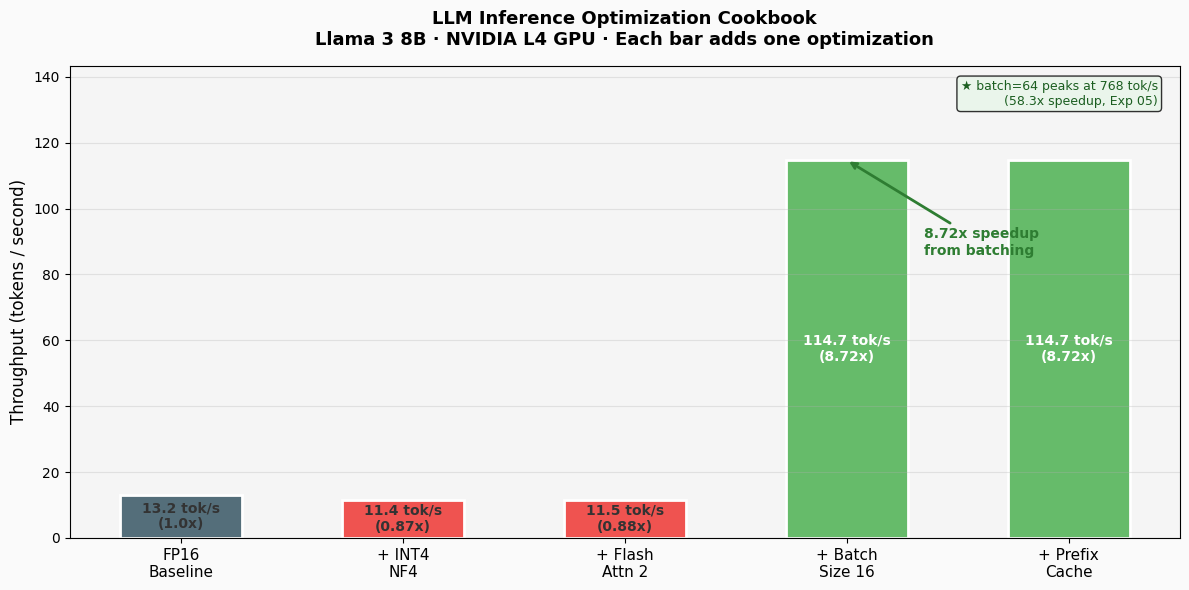

✅ Hero chart saved: /content/drive/MyDrive/llm-inference-cookbook/results/charts/exp08_hero_waterfall_final.png


In [4]:
%matplotlib inline

from IPython.display import display, Image
import matplotlib.pyplot as plt
import numpy as np

steps = [
    ("FP16\nBaseline",    13.16),
    ("+ INT4\nNF4",       11.42),
    ("+ Flash\nAttn 2",   11.54),
    ("+ Batch\nSize 16", 114.71),
    ("+ Prefix\nCache",  114.71),
]

labels      = [s[0] for s in steps]
throughputs = [s[1] for s in steps]
baseline    = throughputs[0]
speedups    = [round(t / baseline, 2) for t in throughputs]
colors      = ['#546E7A', '#EF5350', '#EF5350', '#66BB6A', '#66BB6A']

fig, ax = plt.subplots(figsize=(12, 6))
fig.patch.set_facecolor('#FAFAFA')
ax.set_facecolor('#F5F5F5')

bars = ax.bar(range(len(labels)), throughputs,
              color=colors, edgecolor='white',
              linewidth=2, width=0.55)

# Annotate bars
for bar, val, sp in zip(bars, throughputs, speedups):
    text_color = 'white' if val > 30 else '#333333'
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() / 2,
        f'{val:.1f} tok/s\n({sp}x)',
        ha='center', va='center',
        fontsize=10, fontweight='bold',
        color=text_color
    )

# Arrow pointing to the big jump
ax.annotate(
    '8.72x speedup\nfrom batching',
    xy=(3, throughputs[3]),
    xytext=(3.35, throughputs[3] * 0.75),
    fontsize=10, color='#2E7D32', fontweight='bold',
    arrowprops=dict(arrowstyle='->', color='#2E7D32', lw=2)
)

# Note about batch=64
ax.text(0.98, 0.97,
        '★ batch=64 peaks at 768 tok/s\n   (58.3x speedup, Exp 05)',
        transform=ax.transAxes,
        ha='right', va='top',
        fontsize=9, color='#1B5E20',
        bbox=dict(boxstyle='round', facecolor='#E8F5E9', alpha=0.8))

ax.set_xticks(range(len(labels)))
ax.set_xticklabels(labels, fontsize=11)
ax.set_ylabel('Throughput (tokens / second)', fontsize=12)
ax.set_title(
    'LLM Inference Optimization Cookbook\n'
    'Llama 3 8B · NVIDIA L4 GPU · Each bar adds one optimization',
    fontsize=13, fontweight='bold', pad=15
)
ax.grid(True, alpha=0.3, axis='y')
ax.set_ylim(0, max(throughputs) * 1.25)

plt.tight_layout()
chart_path = f"{CHARTS_DIR}/exp08_hero_waterfall_final.png"
plt.savefig(chart_path, dpi=150, bbox_inches='tight', facecolor='#FAFAFA')
plt.show()
# display(Image(filename=chart_path))
print(f"✅ Hero chart saved: {chart_path}")